In [1]:
import numpy as np
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, cdist
from scipy.stats import f_oneway
from scipy.stats import tukey_hsd
from scipy.stats._hypotests import TukeyHSDResult
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

import pandas as pd
import matplotlib.pyplot as plt

import torch

from visuEmbedding import components_to_fig_3D

from typing import Callable, Optional

import plotly.graph_objects as go

from copy import deepcopy

import random

import tool

# fct

In [4]:
def components_to_fig_3D_simple(
    components: np.ndarray,
    encoder: dict,
    base_color: dict = None,
    default_color: str = "lightgray",
    default_opacity:float =0.1,
    title: str = "3D Representation of Vectors",
    _min: Optional[float] = None,
    _max: Optional[float] = None,
) -> go.Figure:
    
    if base_color is None:
        base_color = {}

    idx_to_word = {idx: word for word, idx in encoder.items()}
    words_ordered = [idx_to_word.get(i, f"vec_{i}") for i in range(components.shape[0])]

    xs = components[:, 0]
    ys = components[:, 1]
    zs = components[:, 2]

    # Handle axes limits
    if _min is None or _max is None:
        max_abs_val = np.max(np.abs(components))
        limit = max_abs_val * 1.1
        if _min is None: _min = -limit
        if _max is None: _max = limit

    fig = go.Figure()

    # --- 1. Plot Background (Other Vectors) ---
    bg_idx = [i for i, w in enumerate(words_ordered) if w not in base_color]
    if bg_idx:
        fig.add_trace(go.Scatter3d(
            x=xs[bg_idx], y=ys[bg_idx], z=zs[bg_idx],
            mode="markers",
            marker=dict(size=3, color=default_color, opacity=default_opacity), # Low opacity
            hovertext=[words_ordered[i] for i in bg_idx],
            hoverinfo="text",
            name="Other words",
            showlegend=True 
        ))

    # --- 2. Plot Highlighted Words (Builds the Legend) ---
    for word, color in base_color.items():
        # Find index of the word (handles in case it's missing or appears multiple times)
        word_idx = [i for i, w in enumerate(words_ordered) if w == word]
        if word_idx:
            fig.add_trace(go.Scatter3d(
                x=xs[word_idx], y=ys[word_idx], z=zs[word_idx],
                mode="markers",
                marker=dict(size=6, color=color, opacity=1.0), # Full opacity, slightly larger
                hovertext=[word] * len(word_idx),
                hoverinfo="text",
                name=word # This adds the word to the legend
            ))

    # --- 3. Axes and Arrows (Unchanged) ---
    max_range = np.max(np.ptp(components, axis=0)) if np.max(np.ptp(components, axis=0)) != 0 else 1.0
    scale = max_range * 0.05

    axes_traces = [
        go.Scatter3d(x=[-scale, scale], y=[0, 0], z=[0, 0], mode="lines", line=dict(color="red", width=4), showlegend=False),
        go.Scatter3d(x=[0, 0], y=[-scale, scale], z=[0, 0], mode="lines", line=dict(color="green", width=4), showlegend=False),
        go.Scatter3d(x=[0, 0], y=[0, 0], z=[-scale, scale], mode="lines", line=dict(color="blue", width=4), showlegend=False),
    ]

    arrow_len = scale * 0.008
    arrow_traces = [
        go.Scatter3d(x=[scale, scale - arrow_len], y=[0, 0], z=[0, 0], mode="lines", line=dict(color="red", width=6), showlegend=False),
        go.Scatter3d(x=[0, 0], y=[scale, scale - arrow_len], z=[0, 0], mode="lines", line=dict(color="green", width=6), showlegend=False),
        go.Scatter3d(x=[0, 0], y=[0, 0], z=[scale, scale - arrow_len], mode="lines", line=dict(color="blue", width=6), showlegend=False)
    ]
    
    labels_traces = [
        go.Scatter3d(x=[scale], y=[0], z=[0], mode="text", text=["X"], textposition="top center", showlegend=False),
        go.Scatter3d(x=[0], y=[scale], z=[0], mode="text", text=["Y"], textposition="top center", showlegend=False),
        go.Scatter3d(x=[0], y=[0], z=[scale], mode="text", text=["Z"], textposition="top center", showlegend=False)
    ]

    for t in axes_traces + arrow_traces + labels_traces:
        fig.add_trace(t)

    fig.update_layout(
        title=title, width=1000, height=800,
        scene=dict(
            xaxis=dict(nticks=4, range=[_min, _max], title="PC1"),
            yaxis=dict(nticks=4, range=[_min, _max], title="PC2"),
            zaxis=dict(nticks=4, range=[_min, _max], title="PC3"),
        ),
        scene_aspectmode="cube",
    )
    
    return fig

def components_to_fig_mollweide(
    components: np.ndarray,
    encoder: dict,
    base_color: dict = None,
    default_color: str = "lightgray",
    title: str = "2D Mollweide Projection of Vectors",
) -> go.Figure:
    """
    Plots all vectors in a 2D Mollweide projection. 
    Points are colored based on base_color mapping. Labels are visible on hover.
    """
    if base_color is None:
        base_color = {}

    # 1. Map rows in the component array back to their words
    idx_to_word = {idx: word for word, idx in encoder.items()}
    words_ordered = [idx_to_word.get(i, f"vec_{i}") for i in range(components.shape[0])]

    # 2. Extract coordinates
    x = components[:, 0]
    y = components[:, 1]
    z = components[:, 2]

    # 3. Calculate Radius, Azimuth, and Elevation
    r = np.sqrt(x**2 + y**2 + z**2)
    # Prevent division by zero if there's a vector exactly at the origin (0,0,0)
    r[r == 0] = 1e-10 
    
    azimuth_rad = np.arctan2(y, x)
    elevation_rad = np.arcsin(z / r)

    # 4. Convert to Degrees for Plotly Scattergeo (Longitude & Latitude)
    lon_deg = np.degrees(azimuth_rad)
    lat_deg = np.degrees(elevation_rad)

    # 5. Create a color list for every single point
    colors = [base_color.get(w, default_color) for w in words_ordered]

    # 6. Initialize figure with Scattergeo
    fig = go.Figure()

    fig.add_trace(
        go.Scattergeo(
            lon=lon_deg,
            lat=lat_deg,
            mode="markers",
            marker=dict(
                size=9, 
                color=colors, 
                opacity=1,
                line=dict(width=0.5, color='white') # Helps separate overlapping dots
            ),
            hovertext=words_ordered,
            hoverinfo="text",
            name="Projected Vectors"
        )
    )

    # 7. Layout settings for Mollweide
    fig.update_layout(
        title=title,
        width=1000, 
        height=600,
        geo=dict(
            projection_type="mollweide",
            showcoastlines=False, # We don't want Earth coastlines on a math plot
            showland=False,
            showocean=False,
            showframe=True,       # Shows the outer oval shape
            # showgrid=True,        # Shows the longitude/latitude curve lines
            # gridcolor="lightgray"
        )
    )
    
    return fig

# See corelation in cosine similarity

## Some test

In [ ]:
def see_corelation_between_df(df1:pd.DataFrame, df2:pd.DataFrame)-> None:
    common_words = df1.index.intersection(df2.index)
    assert len(common_words) > 3, "no suffisent word in common"
    
    common_words = sorted(common_words)
    
    m1_sub = df1.loc[common_words, common_words].values
    m2_sub = df2.loc[common_words, common_words].values
    
    # Get only triangle of 
    upper_indices = np.triu_indices(len(common_words), k=1)
    vec1 = m1_sub[upper_indices]
    vec2 = m2_sub[upper_indices]
    
    corr, p_value = spearmanr(vec1, vec2)
    return corr, p_value

In [ ]:
model = np.load('googleW2V/google_sub_embed_GNG.npz')
model = np.load('embedding/GNG/noNorm/seed_1_OnlyOneEmb_.npz')
# model = np.load('embedding/GNG/norm01/seed_1_SGNS_OneEmbWeighted_.npz')
vec1 = model['vectors']
word1 = model['words']
print(type(word1))
print(len(word1))

model = np.load('embedding/GNG/noNorm/seed_0_OnlyOneEmb_.npz')
# model = np.load('embedding/GNG/norm01/seed_0_SGNS_OneEmbWeighted_.npz')
vec2 = model['vectors']
word2 = model['words']
print(type(word2))

mask = np.isin(word2, word1)

filtered_word2 = word2[mask]
filtered_vec2 = vec2[mask]

print(f"Original word2 size: {len(word2)}")
print(f"Filtered word2 size: {len(filtered_word2)}")

In [ ]:
# 1. Calculate the N x N Cosine Similarity matrices for both models
# This tells us how every word relates to every other word within its own space
print("Calculating similarity matrices...")
sim_matrix1 = cosine_similarity(vec1)
sim_matrix2 = cosine_similarity(filtered_vec2)

# 2. Calculate Spearman correlation for each word's neighborhood
print("Calculating Spearman correlation per word...")
word_correlations = []
for i in range(len(word1)):
    # Compare how word 'i' relates to all other words in Model 1 vs Model 2
    corr, _ = spearmanr(sim_matrix1[i], sim_matrix2[i])
    word_correlations.append(corr)

word_correlations = np.array(word_correlations)

# 3. Filter out the outliers (Keep words with high structural similarity)
# Let's say a correlation > 0.6 means the word's meaning is highly stable across both models
threshold = 0.6
stable_mask = word_correlations > threshold

stable_words = word1[stable_mask]
# We use vec1 for clustering, but you could use vec2 since they are highly correlated here
stable_vectors = word1[stable_mask] 

print(f"Kept {len(stable_words)} stable words out of {len(word1)}")

# 4. Cluster the stable words to find the correlated groups
# DBSCAN is perfect here because it groups dense clusters and labels the rest as noise (-1)
# print("Clustering stable words...")
# clustering = DBSCAN(eps=0.5, min_samples=5, metric='cosine').fit(stable_vectors)

# labels = clustering.labels_

# # 5. Print the results!
# unique_clusters = set(labels)
# for cluster_id in unique_clusters:
#     if cluster_id == -1:
#         continue # Skip the noise cluster
    
#     # Get the words belonging to this cluster
#     cluster_words = stable_words[labels == cluster_id]
#     print(f"\n--- Cluster {cluster_id} (Size: {len(cluster_words)}) ---")
#     # Print the first 10 words as a sample
#     print(", ".join(cluster_words[:10]))

In [ ]:
from scipy.stats._stats_py import SignificanceResult 
res:SignificanceResult = spearmanr(sim_matrix1, sim_matrix2)
print(type(res))
print(res.pvalue)

# See if same Neighbor

## Jaccard Overlap

In [ ]:
def jaccard_overlap(k:int, words:list[str], vectors1:np.ndarray, vectors2:np.ndarray, batch_size:int = 100):
    num_words = len(words)
    jaccard_scores = []
    
    # Normalize vectors
    vectors1 = vectors1 / (np.linalg.norm(vectors1, axis=1, keepdims=True) + 1e-10)
    vectors2 = vectors2 / (np.linalg.norm(vectors2, axis=1, keepdims=True) + 1e-10)
    

    for i in range(0, num_words, batch_size):
        end = min(i + batch_size, num_words)
        
        batch_1 = vectors1[i:end]
        batch_2 = vectors2[i:end]
        
        sims_1 = np.dot(batch_1, vectors1.T) 
        sims_2 = np.dot(batch_2, vectors2.T)
        
        top_k_idx_1 = np.argsort(sims_1, axis=1)[:, -k-1:-1] # Exclude self (last one)
        top_k_idx_2 = np.argsort(sims_2, axis=1)[:, -k-1:-1]
        
        for j in range(len(batch_1)):
            set_g = set(top_k_idx_1[j])
            set_p = set(top_k_idx_2[j])
            
            intersection = len(set_g.intersection(set_p))
            union = len(set_g.union(set_p))
            
            score = intersection / union
            jaccard_scores.append(score)

    
    return jaccard_scores

In [ ]:
def show_plot_jaccard_score(jaccard_scores:list[float]) -> None:
    average_overlap = np.mean(jaccard_scores)
    
    plt.figure(figsize=(10, 6))

    plt.hist(jaccard_scores, bins=50, color='#1f77b4', alpha=0.7, edgecolor='black', range=(0, 1))

    plt.axvline(average_overlap, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {average_overlap:.3f}')

    plt.title('Distribution of Semantic Overlap (Jaccard Similarity)', fontsize=14)
    plt.xlabel('Jaccard Score (0 = No Overlap, 1 = Perfect Match)', fontsize=12)
    plt.ylabel('Number of Words', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(0, 1)
    plt.show()

## All word

In [ ]:
data_google = np.load('googleW2V/google_sub_embed_all_word.npz')
vecs_google = data_google['vectors']
word_google = data_google['words']

my_model = np.load('one_emb_into_all.npz')
vecs_my_model = my_model['vectors']
word_my_model = my_model['words']

In [ ]:
print(word_google)
print(word_my_model)

In [ ]:
data_google = np.load('googleW2V/google_sub_embed_all_word.npz')
vecs_google = data_google['vectors']

my_model = np.load('one_emb_into_all.npz')
vecs_my_model = my_model['vectors']
word_my_model = my_model['words']

jaccord_score = jaccard_overlap(
    vectors2= vecs_my_model,
    vectors1=vecs_google,
    k=10,
    words=word_my_model # Ou word_google (same)
)

show_plot_jaccard_score(jaccord_score)

In [ ]:
data_google = np.load('googleW2V/google_sub_embed_all_word.npz')
vecs_google = data_google['vectors']

my_model = np.load('original_all.npz')
vecs_my_model = my_model['vectors']

average_overlap = jaccard_overlap(
    vectors2= vecs_my_model,
    vectors1=vecs_google,
    k=10,
    words=word_my_model # Ou word_google (same)
)

show_plot_jaccard_score(average_overlap)

In [ ]:
print(len(vecs_my_model))

## Many plot of Jaccard Neighbor

In [ ]:
import math

def show_multi_plot_jaccard(model_scores: dict[str, list[float]], nb_cols:int=2) -> None:
    """
    Chat GPT function
    Plots a grid of histograms comparing Jaccard scores from multiple models.
    
    Args:
        model_scores: A dictionary where Key = Model Name, Value = List of Jaccard Scores
    """
    num_models = len(model_scores)
    
    cols = nb_cols
    rows = math.ceil(num_models / cols)
    
    # Create the figure
    # sharex=True makes comparison easier (all axes align)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True, sharey=False)
    
    # Flatten axes array for easy iteration (handles 1D or 2D arrays)
    if num_models > 1:
        axes = axes.flatten()
    else:
        axes = [axes] # Handle single model case gracefully

    # 2. Iterate and Plot
    for i, (model_name, scores) in enumerate(model_scores.items()):
        ax = axes[i]
        scores_arr = np.array(scores)
        mean_score = np.mean(scores_arr)
        
        # A. Histogram
        ax.hist(scores_arr, bins=50, color='#1f77b4', alpha=0.7, 
                edgecolor='black', range=(0, 1))
        
        # B. Mean Line
        ax.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, 
                   label=f'Mean: {mean_score:.3f}')
        
        # C. Styling
        ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(axis='y', alpha=0.3)
        ax.set_xlim(0, 1)
        
        # Only add Y label to the first column to reduce clutter
        if i % cols == 0:
            ax.set_ylabel('Count of Words')

    # 3. Clean up empty plots
    # If you have 3 models in a 2x2 grid, the 4th plot should be hidden
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Common X label at the bottom
    fig.text(0.5, 0.01, 'Jaccard Score (0 = No Overlap, 1 = Perfect Match)', 
             ha='center', fontsize=12)

    plt.tight_layout()
    # Adjust slightly to make room for the common X label
    plt.subplots_adjust(bottom=0.08) 
    plt.show()

### Comparison avec le W2V de google

In [ ]:
# Important words
google_important_word = np.load('googleW2V/google_sub_embed.npz')
vecs_google_important_word = google_important_word['vectors']
words_gg_iw = google_important_word['words']
print(f"For model : google_important_word , we have : {len(vecs_google_important_word)} words")

one_emb_intonation_important_word = np.load('one_emb_into_imp.npz')
vecs_one_emb_intonation_important_word = one_emb_intonation_important_word['vectors']
words_oei_iw = one_emb_intonation_important_word['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_one_emb_intonation_important_word)} words")

original_important_word = np.load('original_imp.npz')
vecs_original_important_word = original_important_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_original_important_word)} words")

one_emb_important_word = np.load('one_emb_imp.npz')
vecs_one_emb_important_word = one_emb_important_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_one_emb_important_word)} words")

# All words
google_all_word = np.load('googleW2V/google_sub_embed_all_word.npz')
vecs_google_all_word = google_all_word['vectors']
words = google_all_word['words']
print(f"For model : google_important_word , we have : {len(vecs_google_all_word)} words")

one_emb_intonation_all_word = np.load('one_emb_into_all.npz')
vecs_one_emb_intonation_all_word = one_emb_intonation_all_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_one_emb_intonation_all_word)} words")

original_all_word = np.load('original_all.npz')
vecs_original_all_word = original_all_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_original_all_word)} words")

one_emb_all_word = np.load('one_emb_all.npz')
vecs_one_emb_all_word = one_emb_all_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_one_emb_all_word)} words")

# Random vector 
rand_vec_iw = np.random.randn(len(words_gg_iw), 10)
rand_vec_aw = np.random.randn(len(words), 10)

In [ ]:
# Important words
K = 50
K2 = 10
js_oei_iw = jaccard_overlap(
    vectors2=vecs_one_emb_intonation_important_word,
    vectors1=vecs_google_important_word,
    k=K,
    words=words_gg_iw
)
js_o_iw = jaccard_overlap(
    vectors2=vecs_original_important_word,
    vectors1=vecs_google_important_word,
    k=K,
    words=words_gg_iw
)

js_oe_iw = jaccard_overlap(
    vectors2=vecs_one_emb_important_word,
    vectors1=vecs_google_important_word,
    k=K,
    words=words_gg_iw
)

js_r_iw = jaccard_overlap(
    vectors2=rand_vec_iw,
    vectors1=vecs_google_important_word,
    k=K,
    words=words_gg_iw
)

# All words
js_oei_aw = jaccard_overlap(
    vectors2=vecs_one_emb_intonation_all_word,
    vectors1=vecs_google_all_word,
    k=K2,
    words=words
)
js_o_aw = jaccard_overlap(
    vectors2=vecs_original_all_word,
    vectors1=vecs_google_all_word,
    k=K2,
    words=words
)
js_oe_aw = jaccard_overlap(
    vectors2=vecs_one_emb_all_word,
    vectors1=vecs_google_all_word,
    k=K2,
    words=words
)

js_r_aw = jaccard_overlap(
    vectors2=rand_vec_aw,
    vectors1=vecs_google_all_word,
    k=K2,
    words=words
)

# Between model
js_oei_iw_by_o = jaccard_overlap(
    vectors2=vecs_one_emb_intonation_important_word,
    vectors1=vecs_original_important_word,
    k=K,
    words=words_gg_iw
)

js_oe_iw_by_o = jaccard_overlap(
    vectors2=vecs_one_emb_important_word,
    vectors1=vecs_original_important_word,
    k=K,
    words=words_gg_iw
)

js_oei_aw_by_o = jaccard_overlap(
    vectors2=vecs_one_emb_intonation_all_word,
    vectors1=vecs_original_all_word,
    k=K,
    words=words
)

js_oe_aw_by_o = jaccard_overlap(
    vectors2=vecs_one_emb_all_word,
    vectors1=vecs_original_all_word,
    k=K,
    words=words
)


In [ ]:
# verify len of jaccard score
print(f"data set ground trurh : {len(vecs_google_important_word)}")
print(f'One_Emb_Into_Imp : {len(js_oei_iw)}')
print(f'Original_Imp : {len(js_o_iw)}')
print(f"data set ground trurh all word : {len(vecs_google_all_word)}")
print(f'One_Emb_Into_All : {len(js_oei_aw)}')
print(f'Original_All : {len(js_o_aw)}')

In [ ]:
show_multi_plot_jaccard({
    "One_Emb_Into_Imp" : js_oei_iw,
    "Original_Imp" : js_o_iw,
    "One emb" : js_oe_iw,
    "Random" : js_r_iw,
    
    "One_Emb_Into_All" : js_oei_aw,
    "Original_All" : js_o_aw,
    "One emb All" : js_oe_aw,
    "Random 2" : js_r_aw,
    
    "Original and One emb into":js_oei_iw_by_o,
    "Original and One emb":js_oe_iw_by_o,
    "Original and One emb intp all word":js_oei_aw_by_o,
    "Original and One emb all word":js_oe_aw_by_o,
    
}, nb_cols=4)

In [ ]:
print(words_gg_iw)

In [ ]:
print(words_oei_iw)

## See specific word

In [ ]:
decoder_iw = {index : str(value) for index, value in enumerate(words)}
encoder_iw = {str(value) : index for index, value in enumerate(words)}

decoder_aw = {index : str(value) for index, value in enumerate(words)}
encoder_aw = {str(value) : index for index, value in enumerate(words)}

In [ ]:
print(encoder_aw.keys())

In [ ]:
print(js_oei_aw[encoder_aw["gorilla"]])
print(js_o_aw[encoder_aw["gorilla"]])
print(js_oe_aw[encoder_aw["gorilla"]])

In [ ]:
print(decoder_iw.keys())

In [ ]:
best_idx = np.argmax(js_oei_aw)
print(f"Best Aligned Word: '{decoder_aw[best_idx]}' (Score: {js_oei_aw[best_idx]:.2f})")
best_idx = int(np.argmax(js_o_aw))
print(f"Best Aligned Word: '{decoder_aw[best_idx]}' (Score: {js_o_aw[best_idx]:.2f})")
best_idx = int(np.argmax(js_oe_aw))
print(f"Best Aligned Word: '{decoder_aw[best_idx]}' (Score: {js_oe_aw[best_idx]:.2f})")

In [ ]:
top5pourcent = ['flashlight', 'click', 'keys', 'jingle', 'jangle', 'squeak', 'bicycle', 'tire', 'free', 'tiptoe', 'whoosh', 'banana', 'thump', 'bone', 'hyena', 'party', 'strong', 'shell', 'tap', 'parade', 'quietly', 'lawn', 'asleep', 'surprise', 'scuttle', 'cat', 'listen', 'blink', 'light', 'shocked', 'busted', 'march', 'clomp', 'shhh', 'clink', 'snooze', 'snoring', 'zzzz', 'peel']

In [ ]:
for w in top5pourcent:
    index = encoder_aw[w]
    print(f"score for word {w} ; {js_oei_aw[index]:.2f}")
    print(f"score for word {w} ; {js_o_aw[index]:.2f}")
    print(f"score for word {w} ; {js_oe_aw[index]:.2f}")

## See stability of model

## W2V with intonation (One embedding)

In [ ]:
instance_00 = np.load('embedding/seed_5_SGNS_OneEmbWeighted_.npz')
vec_instance_00 = instance_00['vectors']
word_instance_00 = instance_00['words']
print(f"For model : google_important_word , we have : {len(word_instance_00)} words")

instance_01 = np.load('embedding/seed_6_SGNS_OneEmbWeighted_.npz')
vec_instance_01 = instance_01['vectors']
word_instance_01 = instance_01['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_01)} words")

instance_02 = np.load('embedding/seed_7_SGNS_OneEmbWeighted_.npz')
vec_instance_02 = instance_02['vectors']
word_instance_02 = instance_02['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_02)} words")

instance_03 = np.load('embedding/seed_8_SGNS_OneEmbWeighted_.npz')
vec_instance_03 = instance_03['vectors']
word_instance_03 = instance_03['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_03)} words")

instance_04 = np.load('embedding/seed_9_SGNS_OneEmbWeighted_.npz')
vec_instance_04 = instance_04['vectors']
word_instance_04 = instance_04['words']
print(f"For model : google_important_word , we have : {len(word_instance_04)} words")

_random = np.random.randn(len(word_instance_00), 10)

all_word_arrays = [
    word_instance_00, 
    word_instance_01, 
    word_instance_02, 
    word_instance_03, 
    word_instance_04,
]

mismatches = []
for i, words in enumerate(all_word_arrays[1:], start=1):
    if not np.array_equal(word_instance_00, words):
        mismatches.append(i)

if mismatches:
    print(f"ERROR: Words match failed for seeds: {mismatches}")
else:
    print("SUCCESS: All word arrays are identical.")
    
all_vec_arrays = [
    vec_instance_00,
    vec_instance_01,
    vec_instance_02,
    vec_instance_03,
    vec_instance_04,
    _random
]

res_jaccard = {}

for ind1, vec1 in enumerate(all_vec_arrays):
    for ind2, vec2 in enumerate(all_vec_arrays):
        js = jaccard_overlap(vectors1=vec1, vectors2=vec2,
                            k=10, words=word_instance_00)
        res_jaccard[f"Instance n°{ind1} VS n°{ind2}"] = js
        
show_multi_plot_jaccard(res_jaccard, nb_cols=len(all_vec_arrays))

## One Emb

In [ ]:
instance_00 = np.load('embedding/seed_5_OnlyOneEmb_.npz')
vec_instance_00 = instance_00['vectors']
word_instance_00 = instance_00['words']
print(f"For model : google_important_word , we have : {len(word_instance_00)} words")

instance_01 = np.load('embedding/seed_6_OnlyOneEmb_.npz')
vec_instance_01 = instance_01['vectors']
word_instance_01 = instance_01['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_01)} words")

instance_02 = np.load('embedding/seed_7_OnlyOneEmb_.npz')
vec_instance_02 = instance_02['vectors']
word_instance_02 = instance_02['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_02)} words")

instance_03 = np.load('embedding/seed_8_OnlyOneEmb_.npz')
vec_instance_03 = instance_03['vectors']
word_instance_03 = instance_03['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_03)} words")

instance_04 = np.load('embedding/seed_9_OnlyOneEmb_.npz')
vec_instance_04 = instance_04['vectors']
word_instance_04 = instance_04['words']
print(f"For model : google_important_word , we have : {len(word_instance_04)} words")

_random = np.random.randn(len(word_instance_00), 10)

all_word_arrays = [
    word_instance_00, 
    word_instance_01, 
    word_instance_02, 
    word_instance_03, 
    word_instance_04
]

mismatches = []
for i, words in enumerate(all_word_arrays[1:], start=1):
    if not np.array_equal(word_instance_00, words):
        mismatches.append(i)

if mismatches:
    print(f"ERROR: Words match failed for seeds: {mismatches}")
else:
    print("SUCCESS: All word arrays are identical.")
    
all_vec_arrays = [
    vec_instance_00,
    vec_instance_01,
    vec_instance_02,
    vec_instance_03,
    vec_instance_04,
    _random
]

res_jaccard = {}

for ind1, vec1 in enumerate(all_vec_arrays):
    for ind2, vec2 in enumerate(all_vec_arrays):
        js = jaccard_overlap(vectors1=vec1, vectors2=vec2,
                            k=80, words=word_instance_00)
        res_jaccard[f"Instance n°{ind1} VS n°{ind2}"] = js
        
show_multi_plot_jaccard(res_jaccard, nb_cols=len(all_vec_arrays))

## Two embedding

In [ ]:
instance_00 = np.load('embedding/seed_5_SkipGramModel_.npz')
vec_instance_00 = instance_00['vectors']
word_instance_00 = instance_00['words']
print(f"For model : google_important_word , we have : {len(word_instance_00)} words")

instance_01 = np.load('embedding/seed_6_SkipGramModel_.npz')
vec_instance_01 = instance_01['vectors']
word_instance_01 = instance_01['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_01)} words")

instance_02 = np.load('embedding/seed_7_SkipGramModel_.npz')
vec_instance_02 = instance_02['vectors']
word_instance_02 = instance_02['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_02)} words")

instance_03 = np.load('embedding/seed_8_SkipGramModel_.npz')
vec_instance_03 = instance_03['vectors']
word_instance_03 = instance_03['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(word_instance_03)} words")

instance_04 = np.load('embedding/seed_9_SkipGramModel_.npz')
vec_instance_04 = instance_04['vectors']
word_instance_04 = instance_04['words']
print(f"For model : google_important_word , we have : {len(word_instance_04)} words")

_random = np.random.randn(len(word_instance_00), 10)

all_word_arrays = [
    word_instance_00, 
    word_instance_01, 
    word_instance_02, 
    word_instance_03, 
    word_instance_04
]

mismatches = []
for i, words in enumerate(all_word_arrays[1:], start=1):
    if not np.array_equal(word_instance_00, words):
        mismatches.append(i)

if mismatches:
    print(f"ERROR: Words match failed for seeds: {mismatches}")
else:
    print("SUCCESS: All word arrays are identical.")
    
all_vec_arrays = [
    vec_instance_00,
    vec_instance_01,
    vec_instance_02,
    vec_instance_03,
    vec_instance_04,
    _random
]

res_jaccard = {}

for ind1, vec1 in enumerate(all_vec_arrays):
    for ind2, vec2 in enumerate(all_vec_arrays):
        js = jaccard_overlap(vectors1=vec1, vectors2=vec2,
                            k=10, words=word_instance_00)
        res_jaccard[f"Instance n°{ind1} VS n°{ind2}"] = js
        
show_multi_plot_jaccard(res_jaccard, nb_cols=len(all_vec_arrays))

# Mean Absolute Rank Error (MARE)

In [ ]:
def compute_mare(matrix_gold:np.ndarray, matrix_to_compare:np.ndarray, top_k:int=10)->float:
    """
    Docstring for compute_mare
    
    :param matrix_gold: Gold matrix of vector, is the reference 
    :type matrix_gold: np.ndarray
    :param matrix_to_compare: Vector matrix to be compared with the gold matrix
    :type matrix_to_compare: np.ndarray
    :param top_k: To avoid outlier, we not take all word because we have lot of noise word.
    :type top_k: int
    :return: Metric
    :rtype: float
    """
    
    norm_gold:np.ndarray = matrix_gold / np.linalg.norm(matrix_gold, axis=1, keepdims=True)
    norm_to_compare:np.ndarray = matrix_to_compare / np.linalg.norm(matrix_to_compare, axis=1, keepdims=True)
    
    sim_gold = np.dot(norm_gold, norm_gold.T) # Get matrix of similarity
    sim_to_compare = np.dot(norm_to_compare, norm_to_compare.T)
    
    ranks_gold = np.argsort(np.argsort(-sim_gold, axis=1), axis=1)
    ranks_to_compare = np.argsort(np.argsort(-sim_to_compare, axis=1), axis=1)
    
    top_gold_neighbors_indices = np.argsort(-sim_gold, axis=1)[:, 1:top_k+1]
    
    forward_errors = []
    rows = norm_to_compare.shape[0]
    
    for row_idx in range(rows):
        gold_neighbor_indices = top_gold_neighbors_indices[row_idx]
        r_gold = ranks_gold[row_idx, gold_neighbor_indices]
        r_gold = range(1, top_k +1)
        r_to_compare = ranks_to_compare[row_idx, gold_neighbor_indices]
        forward_errors.extend(np.abs(r_to_compare - r_gold))
    mare_fwd = np.mean(forward_errors)
    
    top_to_compare_neighbors_indices = np.argsort(-sim_to_compare, axis=1)[:, 1:top_k+1]
    backward_errors = []
    for i in range(rows):
        neighbor_indices = top_to_compare_neighbors_indices[i]
        # r_to_compare = ranks_to_compare[i, neighbor_indices]
        r_to_compare = range(1, top_k +1)
        
        r_gold = ranks_gold[i, neighbor_indices]

        backward_errors.extend(np.abs(r_to_compare - r_gold))
        
    mare_bwd = np.mean(backward_errors)
    
    
    return mare_fwd, mare_bwd

In [ ]:
# Important words
google_important_word = np.load('googleW2V/google_sub_embed.npz')
vecs_google_important_word = google_important_word['vectors']
words_gg_iw = google_important_word['words']
print(f"For model : google_important_word , we have : {len(vecs_google_important_word)} words")

one_emb_intonation_important_word = np.load('one_emb_into_imp.npz')
vecs_one_emb_intonation_important_word = one_emb_intonation_important_word['vectors']
words_oei_iw = one_emb_intonation_important_word['words']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_one_emb_intonation_important_word)} words")

original_important_word = np.load('original_imp.npz')
vecs_original_important_word = original_important_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_original_important_word)} words")

one_emb_important_word = np.load('one_emb_imp.npz')
vecs_one_emb_important_word = one_emb_important_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_one_emb_important_word)} words")

# All words
google_all_word = np.load('googleW2V/google_sub_embed_all_word.npz')
vecs_google_all_word = google_all_word['vectors']
words = google_all_word['words']
print(f"For model : google_important_word , we have : {len(vecs_google_all_word)} words")

one_emb_intonation_all_word = np.load('one_emb_into_all.npz')
vecs_one_emb_intonation_all_word = one_emb_intonation_all_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_one_emb_intonation_all_word)} words")

original_all_word = np.load('original_all.npz')
vecs_original_all_word = original_all_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_original_all_word)} words")

one_emb_all_word = np.load('one_emb_all.npz')
vecs_one_emb_all_word = one_emb_all_word['vectors']
print(f"For model : one_emb_intonation_important_word , we have : {len(vecs_one_emb_all_word)} words")

# Random vector 
rand_vec_iw = np.random.randn(len(words_gg_iw), 10)
rand_vec_aw = np.random.randn(len(words), 10)

In [ ]:
print(compute_mare(matrix_gold= vecs_google_important_word,
                   matrix_to_compare= vecs_one_emb_intonation_important_word,
                   top_k=10
                   ))

print(compute_mare(matrix_gold= vecs_google_important_word,
                   matrix_to_compare= vecs_original_important_word,
                   top_k=10
                   ))

print(compute_mare(matrix_gold= vecs_google_important_word,
                   matrix_to_compare= rand_vec_iw,
                   top_k=10
                   ))

# (Manual or not) cluster

## Function for clusters
- compute_distance_euclidien
- my_distance_euclidien (different pre traitement before compute distance euclidien)
- compute_distance_rank_by_cluster (compute Z_score, (cluster sim - global sim) / global std)
- apply_metrics_with_clusters_in_vectors (load weights and apply a list of function in weight)
- compute_MAE_with_referential_value (compute MAE)
- compute_MAE_for_each_cluster, compute_globale_MAE, make_MAE_for_each_model
- make_ratio_for_each_model (divise many score by ground truth)
- pipeline_metric_and_MAE_and_ratio (compute MAE and Z_score)
- pipeline_metric_ratio_of_z_score (pipeline for only z_score)

In [5]:
def compute_distance_euclidien(vectors:np.ndarray, index_of_cluster:list[int], nb_outliers:int|None=100) -> dict:
    cluster_vectors = vectors[index_of_cluster]
    intra_distances = pdist(cluster_vectors, metric='euclidean')
    mean_intra_dist = np.mean(intra_distances)
    
    all_indices = np.arange(len(vectors))
    mask = np.isin(all_indices, index_of_cluster, invert=True)
    outside_indices = all_indices[mask]
    random_outside_indices = np.random.choice(outside_indices, size=nb_outliers, replace=False)
    outside_vectors = vectors[random_outside_indices]
    
    inter_distances = cdist(cluster_vectors, outside_vectors, metric='euclidean')
    mean_inter_dist = np.mean(inter_distances)


    return {
            "avg_dist_within_cluster": float(mean_intra_dist),
            "avg_dist_to_outsiders": float(mean_inter_dist),
            "ratio": float(mean_inter_dist / mean_intra_dist)
        }
    
def my_distance_euclidien(vectors:np.ndarray, index_of_cluster:list[int], nb_outliers:int|None=100) -> dict:
    result = {
        "no_traitement" : None,
        "PCA" : None,
        "norm" : None,
        "PCA and norm" : None,
    }
    
    result["no_traitement"] = compute_distance_euclidien(vectors, index_of_cluster, nb_outliers)
    
    pca = PCA(n_components=3)
    vectors_pca = pca.fit_transform(vectors)
    result["PCA"] = compute_distance_euclidien(vectors_pca, index_of_cluster, nb_outliers)
    
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms[norms == 0] = 1e-10 
    vectors_norm = vectors / norms
    result["norm"] = compute_distance_euclidien(vectors_norm, index_of_cluster, nb_outliers)
    
    norms_pca = np.linalg.norm(vectors_pca, axis=1, keepdims=True)
    norms_pca[norms_pca == 0] = 1e-10
    vectors_pca_norm = vectors_pca / norms_pca
    result["PCA and norm"] = compute_distance_euclidien(vectors_pca_norm, index_of_cluster, nb_outliers)

    return result

def compute_distance_rank_by_cluster(model_vectors:np.ndarray, cluster_index:list[int], n_random_samples=None):
    vectors = torch.tensor(model_vectors)
    norms = vectors.norm(dim=1, keepdim=True)
    vectors_norm = vectors / norms
    
    cluster_vecs = vectors_norm[cluster_index]
    sim_matrix = torch.mm(cluster_vecs, cluster_vecs.t()) # Dot product of normalized vectors = Cosine Similarity
    
    mask = torch.triu(
        torch.ones(len(cluster_index), len(cluster_index)), diagonal=1).bool() # Get upper triangle only (exclude diagonal 1.0s and duplicates)
    cluster_sim_mean = sim_matrix[mask].mean().item()

    num_vocab = len(model_vectors)
    if n_random_samples is None :
        global_sim_matrix = torch.mm(vectors_norm, vectors_norm.t())
        global_mask = torch.triu(torch.ones(num_vocab, num_vocab), diagonal=1).bool()
        global_sims = global_sim_matrix[global_mask]
        
        global_mean = global_sims.mean().item()
        global_std = global_sims.std().item()
        
    else :
        idx_a = torch.randint(0, num_vocab, (n_random_samples,))
        idx_b = torch.randint(0, num_vocab, (n_random_samples,))
        
        # Ensure we don't accidentally compare a word to itself
        valid_pairs_mask = idx_a != idx_b
        idx_a = idx_a[valid_pairs_mask]
        idx_b = idx_b[valid_pairs_mask]
    
        vecs_a = vectors_norm[idx_a]
        vecs_b = vectors_norm[idx_b]

        global_sims = (vecs_a * vecs_b).sum(dim=1) 
        
        global_mean = global_sims.mean().item()
        global_std = global_sims.std().item()

    if global_std == 0:
        z_score = 0.0 
    else:
        z_score = (cluster_sim_mean - global_mean) / global_std
        # print(f"z score :  {z_score:4f} with sim cluster : {cluster_sim_mean:4f} global mean : {global_mean:4f} and global std {global_std:4f}")
    
    return {
        "z_score": z_score,
        "raw_cluster_sim": cluster_sim_mean,
        "global_mean": global_mean,
        "global_std": global_std
    }
    
def apply_metrics_with_clusters_in_vectors(
        paths_of_weight:list[str], 
        clusters:dict[str, list[str]],
        fct_metrics:list[Callable],
        n_random_samples=100
    ) -> dict:
    result = {
        i: {m.__name__: [] for m in fct_metrics} 
        for i in clusters.keys()
    }
    
    for path_w in paths_of_weight:
        name_file = path_w
        model = np.load(name_file)
        vecs = model['vectors']
        words = model['words']
        encoder = {str(w): i for i, w in enumerate(words)}
        
        for key, cl in clusters.items():
            valid_words = set(cl).intersection(encoder.keys())
            index_cluster = [encoder[w] for w in valid_words]
    
            for metric in fct_metrics:
                metric_name = metric.__name__
                metric_val = metric(vecs, index_cluster, n_random_samples)
                result[key][metric_name].append(metric_val)                
        
    return result

def compute_MAE_with_referential_value(z_base: float, z_targets: list[float]):
    """
    Compute the mean absolute error (MAE) and its standard deviation between a referential value
    and a list of target values.

    Parameters
    ----------
    z_base : float
        Referential value to compare against.
    z_targets : list[float]
        Target values to compare to the referential value.

    Returns
    -------
    tuple[float, float]
        (mae, mae_std) where mae is the mean absolute error and mae_std is the standard deviation
        of the absolute errors.

    Example
    -------
    >>> compute_MAE_with_referential_value(1.0, [1.2, 0.8, 1.0])
    (0.13333333333333333, 0.1643989873053573)
    """
    absolute_errors = np.abs([el - z_base for el in z_targets])
    mae = np.mean(absolute_errors)
    mae_std = np.std(absolute_errors)
    return mae, mae_std


def compute_MAE_for_each_cluster(referential_values: list[float], comparing_values: list[list[float]]):
    """
    Compute MAE and its standard deviation for each pair of referential value and corresponding
    list of comparison values (one result per cluster).

    Parameters
    ----------
    referential_values : list[float]
        Referential value for each cluster.
    comparing_values : list[list[float]]
        List of lists where each inner list contains values to compare with the corresponding
        referential value.

    Returns
    -------
    list[tuple[float, float]]
        A list of (mae, mae_std) tuples, one per cluster in the same order as the inputs.

    Example
    -------
    >>> compute_MAE_for_each_cluster([1.0, 2.0], [[1.1, 0.9], [2.2, 1.8]])
    [(0.10000000000000009, 0.09999999999999998), (0.19999999999999996, 0.19999999999999996)]
    """
    result: list[tuple[float, float]] = []
    for r_value, comp_values in zip(referential_values, comparing_values):
        result.append(compute_MAE_with_referential_value(r_value, comp_values))
    return result


def compute_globale_MAE(referential_values: list[float], comparing_values: list[list[float]]):
    """
    Compute a global MAE (mean and std) across all clusters by aggregating absolute errors
    between each referential value and its corresponding comparison values.

    Parameters
    ----------
    referential_values : list[float]
        Referential value for each cluster.
    comparing_values : list[list[float]]
        List of lists where each inner list contains values to compare with the corresponding
        referential value.

    Returns
    -------
    tuple[float, float]
        (mean_MAE, std_MAE) computed over all absolute errors from all clusters.

    Example
    -------
    >>> compute_globale_MAE([1.0, 2.0], [[1.1, 0.9], [2.2, 1.8]])
    (0.15000000000000002, 0.07500000000000001)
    """
    all_MAE = []
    for r_value, comp_values in zip(referential_values, comparing_values):
        all_MAE.extend(np.abs([el - r_value for el in comp_values]))

    mean_MAE = np.mean(all_MAE)
    std_MAE = np.std(all_MAE)
    return mean_MAE, std_MAE

def make_MAE_for_each_model(dict_list_metric:dict[str, dict], ground_truth:dict):
    MAE_by_model:dict[str, dict] = {m : {} for m in dict_list_metric.keys()}
    for model_name, metric_by_cluster in dict_list_metric.items():
        for name_cluster in metric_by_cluster.keys():
            MAE_by_model[model_name][name_cluster] = compute_MAE_with_referential_value(
                                                        ground_truth[name_cluster], dict_list_metric[model_name][name_cluster])
    return MAE_by_model

def make_ratio_for_each_model(zscore_by_cluster_by_model:dict[str, dict], ground_truth_by_cluster:dict):
    list_zscore_ratio_by_cl_by_model:dict[str, dict[str, dict]] = {m : {} for m in zscore_by_cluster_by_model.keys()}
    for model_name, metric_by_cluster in zscore_by_cluster_by_model.items():
        for name_cluster, scores in metric_by_cluster.items():
            list_zscore_ratio_by_cl_by_model[model_name][name_cluster] = np.divide(scores, ground_truth_by_cluster[name_cluster])
    return list_zscore_ratio_by_cl_by_model
    
def pipeline_metric_and_MAE_and_ratio(dict_of_models_paths:dict, path_ground_truth:str, different_cluster:dict):
    metric_by_model = {name_model: {} for name_model in dict_of_models_paths.keys()}
    for name_model, paths_model_by_seeds in dict_of_models_paths.items():
        metric_by_model[name_model] = apply_metrics_with_clusters_in_vectors(
            clusters=different_cluster,
            fct_metrics=[compute_distance_rank_by_cluster],
            n_random_samples=None,
            paths_of_weight=paths_model_by_seeds
        )
        
    dict_list_metric = {name_m : {} for name_m in metric_by_model.keys()}
    for name_cl in different_cluster.keys():
        for model_name in metric_by_model.keys():
            dict_list_metric[model_name][name_cl] = [metric["z_score"] 
                                            for metric in metric_by_model[model_name][name_cl]["compute_distance_rank_by_cluster"]]
        
    model_ground_truth = apply_metrics_with_clusters_in_vectors(
        clusters=different_cluster,
        fct_metrics=[compute_distance_rank_by_cluster],
        n_random_samples=None,
        paths_of_weight=[path_ground_truth]
    )
    
    ground_truth = {}
    for cl in different_cluster.keys():
        ground_truth[cl] = model_ground_truth[cl]["compute_distance_rank_by_cluster"][0]["z_score"]
    
    
    mae = make_MAE_for_each_model(dict_list_metric=dict_list_metric,
                                  ground_truth=ground_truth)
    
    ratio = make_ratio_for_each_model(zscore_by_cluster_by_model=dict_list_metric,
                                  ground_truth_by_cluster=ground_truth)
    
    metric_by_model["SGNS pretrain"] = model_ground_truth
    
    return (metric_by_model, mae, ratio)

def pipeline_metric_ratio_of_z_score(
    dict_of_models_paths:dict,
    path_ground_truth:str,
    different_cluster:dict
):
    """
    """
    metric_by_model = {name_model: {} for name_model in dict_of_models_paths.keys()}
    for name_model, paths_model_by_seeds in dict_of_models_paths.items():
        metric_by_model[name_model] = apply_metrics_with_clusters_in_vectors(
            clusters=different_cluster,
            fct_metrics=[compute_distance_rank_by_cluster],
            n_random_samples=None,
            paths_of_weight=paths_model_by_seeds
        )
        
    dict_list_metric = {name_m : {} for name_m in metric_by_model.keys()}
    for name_cl in different_cluster.keys():
        for model_name in metric_by_model.keys():
            dict_list_metric[model_name][name_cl] = [metric["z_score"] 
                                            for metric in metric_by_model[model_name][name_cl]["compute_distance_rank_by_cluster"]]
        
    model_ground_truth = apply_metrics_with_clusters_in_vectors(
        clusters=different_cluster,
        fct_metrics=[compute_distance_rank_by_cluster],
        n_random_samples=None,
        paths_of_weight=[path_ground_truth]
    )
    
    ground_truth = {}
    for cl in different_cluster.keys():
        ground_truth[cl] = model_ground_truth[cl]["compute_distance_rank_by_cluster"][0]["z_score"]
    
    
    ratio = make_ratio_for_each_model(zscore_by_cluster_by_model=dict_list_metric,
                                  ground_truth_by_cluster=ground_truth)
    
    metric_by_model["SGNS pretrain"] = model_ground_truth
    
    return (metric_by_model, ratio)

def global_vec(vectors:torch.Tensor):
    vec_mean = vectors.mean(dim=0)
    std = vectors.std(dim=0)
    print(vec_mean)
    return vec_mean, std

def global_cosine_sim(vectors: torch.Tensor):
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)
    sim_matrix = torch.mm(vectors_norm, vectors_norm.t()) 
    
    number_vec = len(vectors)
    mask = torch.triu(torch.ones(number_vec, number_vec, device=vectors.device), diagonal=1).bool()
    unique_sims = sim_matrix[mask]
    
    return (unique_sims.mean().item(), unique_sims.std().item())

## Compute

### Define cluster and corpus to test

In [6]:
# Define cluster
min_similarity=0.4
min_words=5

corpus_emb = {
    "GNG" : "googleW2V/google_sub_embed_GNG.npz",
    "IWW" : "googleW2V/google_sub_embed_IWW.npz",
    "TGTR" : "googleW2V/google_sub_embed_TGTR.npz",
    "TGTP" : "googleW2V/google_sub_embed_TGTP.npz",
    "TS_GNG_IWW" : "googleW2V/google_sub_embed_TS_GNG_IWW.npz",
    "GNG_IWW" : "googleW2V/google_sub_embed_GNG_IWW.npz",
    "TS" : "googleW2V/google_sub_embed_TS.npz",
    "TSGE" : "googleW2V/google_sub_embed_TSGE.npz",
    "GNG_IWW_TSGE" : "googleW2V/google_sub_embed_GNG_IWW_TSGE.npz",
    "TRDP" : "googleW2V/google_sub_embed_TRDP.npz",
    "GNG_IWW_TSGE_TRDP" : "googleW2V/google_sub_embed_GNG_IWW_TSGE_TRDP.npz",
    "GNG_IWW_TSGE_TRDP_TGTP" : "googleW2V/google_sub_embed_GNG_IWW_TSGE_TRDP_TGTP.npz",
    "GNG_IWW_TSGE_TRDP_TGTP_TGTR" : "googleW2V/google_sub_embed_GNG_IWW_TSGE_TRDP_TGTP_TGTR.npz",
}



list_df_sim = []
cluster_by_corpus = {}
for corpus_name, corpus_path in corpus_emb.items():
    model_tempo = np.load(corpus_path)
    vecs = model_tempo['vectors']
    words = model_tempo['words']
    df_sim = tool.compute_all_sim(vecs=vecs, words=words)
    list_df_sim.append(df_sim)
    all_clusters = tool.create_all_clusters(df_sim, min_similarity=min_similarity)
    best_clusters = tool.find_good_clusters(all_clusters, df_sim, min_words=min_words)
    cluster_by_corpus[corpus_name] = best_clusters
    # print(f"\n--- Top Clusters ({len(best_clusters)}) by Cohesion (Tightness) for {corpus_name} ---")
    # for cluster_id, score, std_score, words in best_clusters:
    #     print(f"Cluster {cluster_id} | Cohesion: {score:.3f}  +- {std_score:.2f}| Words: {words}")

# cluster_by_corpus["GNG_IWW_TSGE_TRDP_TGTP"].extend(cluster_by_corpus["GNG"])
# cluster_by_corpus["GNG_IWW_TSGE_TRDP_TGTP"] = cluster_by_corpus["TSGE"]
for corpus, c in cluster_by_corpus.items():
    print(f"For {corpus} we have {len(c)}")
    for cluster_id, score, std_score, words in c:
        print(f"Cluster {cluster_id} | Cohesion: {score:.3f}  +- {std_score:.2f}| Words: {words}")

For GNG we have 7
Cluster 162 | Cohesion: 0.604  +- 0.09| Words: ['did', 'do', 'does', 'going', 'not', 'want']
Cluster 118 | Cohesion: 0.595  +- 0.10| Words: ['black', 'blue', 'orange', 'pink', 'purple', 'white', 'yellow']
Cluster 33 | Cohesion: 0.569  +- 0.06| Words: ['asleep', 'awake', 'bed', 'sleep', 'sleeping']
Cluster 38 | Cohesion: 0.557  +- 0.06| Words: ['cat', 'elephant', 'giraffe', 'gorilla', 'monkey']
Cluster 87 | Cohesion: 0.553  +- 0.07| Words: ['away', 'back', 'down', 'off', 'out', 'up']
Cluster 164 | Cohesion: 0.545  +- 0.10| Words: ['here', 'just', 'me', 'really', 'us']
Cluster 168 | Cohesion: 0.526  +- 0.08| Words: ['because', 'but', 'even', 'it', 'never', 'that']
For IWW we have 4
Cluster 78 | Cohesion: 0.611  +- 0.08| Words: ['did', 'do', 'does', 'let', 'not']
Cluster 79 | Cohesion: 0.585  +- 0.08| Words: ['black', 'blue', 'brown', 'orange', 'pink', 'red', 'yellow']
Cluster 154 | Cohesion: 0.551  +- 0.08| Words: ['cat', 'dog', 'doggy', 'furry', 'paws']
Cluster 62 | Co

### Compute difference between Google W2V and other method

In [7]:
r = range(0, 10)
all_res = {}
all_corpus_cluster_MAE_by_model = {}
all_result_by_corpus = {}
all_ratio_by_corpus = {}
for corpus in ["GNG", "IWW", "TSGE", "TGTP", "TGTR", "GNG_IWW", "GNG_IWW_TSGE", "GNG_IWW_TSGE_TRDP", 'GNG_IWW_TSGE_TRDP_TGTP', 'GNG_IWW_TSGE_TRDP_TGTP_TGTR']:
# for corpus in ["GNG_IWW_TSGE_TRDP"]:
    all_corpus_cluster_MAE_by_model[corpus] = {}
    different_cluster =  {i: words for i, (_, _, _, words) in enumerate(cluster_by_corpus[corpus])}   
    dict_of_models_paths = {
        "My method with intonation" : [f"embedding/{corpus}/norm01/seed_{i}_SGNS_OneEmbWeighted_.npz" for i in r],
        # "My method with intonation Other Norm" : [f"embedding/{corpus}/norm04/seed_{i}_SGNS_OneEmbWeighted_.npz" for i in r],
        "My method without intonation" : [f"embedding/{corpus}/noNorm/seed_{i}_OnlyOneEmb_.npz" for i in r],
        "SGNS with intonation" : [f"embedding/{corpus}/norm01/seed_{i}_SGNS_Weighted_.npz" for i in r],
        # "SGNS with intonation Other Norm" : [f"embedding/{corpus}/norm04/seed_{i}_SGNS_Weighted_.npz" for i in r],
        "SGNS without intonation" : [f"embedding/{corpus}/noNorm/seed_{i}_SkipGramModel_.npz" for i in r],
        # "TwoEmbSGD" : [f"embedding/{corpus}/SGM/seed_{i}_SkipGramModel_.npz" for i in r],
    }
    
    metric_Zscore, result, ratio = pipeline_metric_and_MAE_and_ratio(
        dict_of_models_paths=dict_of_models_paths,
        different_cluster=different_cluster,
        path_ground_truth=f"googleW2V/google_sub_embed_{corpus}.npz"
    )
    
    all_result_by_corpus[corpus]=metric_Zscore
    all_ratio_by_corpus[corpus]=ratio
    
    mean_by_model = {}
    cluster_MAE_by_model = {m : {} for m in dict_of_models_paths.keys()}
    for model, dict_mae in result.items():
        for c, v in dict_mae.items():
            cluster_MAE_by_model[model][c] = v[0]
            
        mean_by_model[model] = np.mean([v[0] for v in dict_mae.values()])
    all_res[corpus] = mean_by_model
    all_corpus_cluster_MAE_by_model[corpus] = cluster_MAE_by_model
    # print(mean_by_model)
    
print(all_corpus_cluster_MAE_by_model)

{'GNG': {'My method with intonation': {0: np.float64(3.765750738012565), 1: np.float64(4.454320431437843), 2: np.float64(3.842758038703626), 3: np.float64(3.4633117278882475), 4: np.float64(3.8454365912729407), 5: np.float64(2.927286519313415), 6: np.float64(2.4622125154642758)}, 'My method without intonation': {0: np.float64(4.527596442231736), 1: np.float64(4.393466468466969), 2: np.float64(4.507410473309028), 3: np.float64(4.588911068694307), 4: np.float64(4.416332950701622), 5: np.float64(4.24821758863707), 6: np.float64(3.9970483490206816)}, 'SGNS with intonation': {0: np.float64(4.502578815477589), 1: np.float64(4.74699499522004), 2: np.float64(4.22489827811024), 3: np.float64(4.1372797876508205), 4: np.float64(4.175663662909339), 5: np.float64(4.3980077015855255), 6: np.float64(3.5720454153270422)}, 'SGNS without intonation': {0: np.float64(4.252244505474397), 1: np.float64(4.723201797235573), 2: np.float64(4.314614621399943), 3: np.float64(4.093033981690413), 4: np.float64(4.02

In [8]:
for corpus in ["GNG", "IWW", "TSGE", "TGTP", "TGTR", "GNG_IWW", "GNG_IWW_TSGE", "GNG_IWW_TSGE_TRDP", 'GNG_IWW_TSGE_TRDP_TGTP', 'GNG_IWW_TSGE_TRDP_TGTP_TGTR']:
    all_corpus_cluster_MAE_by_model[corpus] = {}
    different_cluster =  {i: words for i, (_, _, _, words) in enumerate(cluster_by_corpus[corpus])}   
    dict_of_models_paths = {
        "My method with intonation" : [f"embedding/{corpus}/norm01/seed_{i}_SGNS_OneEmbWeighted_.npz" for i in r],
        # "My method without intonation" : [f"embedding/{corpus}/noNorm/seed_{i}_OnlyOneEmb_.npz" for i in r],
        # "SGNS with intonation" : [f"embedding/{corpus}/norm01/seed_{i}_SGNS_Weighted_.npz" for i in r],
        # "SGNS without intonation" : [f"embedding/{corpus}/noNorm/seed_{i}_SkipGramModel_.npz" for i in r],
        
        # "TwoEmbSGD" : [f"embedding/{corpus}/SGM/seed_{i}_SkipGramModel_.npz" for i in r],
        # "SGNS with intonation Other Norm" : [f"embedding/{corpus}/norm04/seed_{i}_SGNS_Weighted_.npz" for i in r],
        # "My method with intonation Other Norm" : [f"embedding/{corpus}/norm04/seed_{i}_SGNS_OneEmbWeighted_.npz" for i in r],
    }
    print(f"\n======{corpus}======")
    for model, paths in dict_of_models_paths.items():
        _model = np.load(paths[0])
        vecs = _model['vectors']
        words = _model['words']
        vecs_tensor = torch.tensor(vecs)
        m, std = global_cosine_sim(vecs_tensor)
        vec_m, vec_std = global_vec(vecs_tensor)
        print(f"for the model : {model} we have mean {m} and std {std}")
        print(f"                        we have vec mean {vec_m} and std {vec_std}")
        
    


======GNG======
tensor([-0.1115, -0.1110,  0.0918,  0.0123, -0.0809, -0.0069,  0.0456,  0.0419,
         0.0481,  0.0248])
for the model : My method with intonation we have mean 0.013750876300036907 and std 0.3468192517757416
                        we have vec mean tensor([-0.1115, -0.1110,  0.0918,  0.0123, -0.0809, -0.0069,  0.0456,  0.0419,
         0.0481,  0.0248]) and std tensor([0.3715, 0.3947, 0.4827, 0.3754, 0.4688, 0.3024, 0.4229, 0.4459, 0.3194,
        0.2935])

======IWW======
tensor([ 0.0302,  0.0080,  0.0885, -0.1406, -0.0406, -0.0003,  0.0359,  0.0248,
        -0.0037, -0.0220])
for the model : My method with intonation we have mean 0.01896180771291256 and std 0.3272407054901123
                        we have vec mean tensor([ 0.0302,  0.0080,  0.0885, -0.1406, -0.0406, -0.0003,  0.0359,  0.0248,
        -0.0037, -0.0220]) and std tensor([0.3593, 0.2949, 0.3770, 0.3713, 0.3209, 0.4099, 0.4206, 0.3423, 0.2975,
        0.3008])

======TSGE======
tensor([ 0.0725, -0.063

In [ ]:
all_result_by_model = {}
for corpus, value in all_ratio_by_corpus.items():
    if corpus in ["IWW", "TGTR"]:
        continue
    for key, value2 in value.items():
        for _, value3 in value2.items():
            if key not in all_result_by_model:
                all_result_by_model[key] = value3.tolist()
            else:
                all_result_by_model[key].extend(value3.tolist())

In [ ]:
f_stat, p_value = f_oneway(*all_result_by_model.values())
print(f"f_stat : {f_stat:.5f} , P-value : {p_value:.2e}")

print(all_result_by_model)
res = tukey_hsd(*all_result_by_model.values())
print(res)

In [9]:
number_word_by_corpus = {}
number_word_by_corpus = {
    "GNG" : 1910,
    "GNG_IWW": 3359,
    "GNG_IWW_TSGE": 4368,
    "GNG_IWW_TSGE_TRDP": 6256,
    "GNG_IWW_TSGE_TRDP_TGTP": 7971,
    "GNG_IWW_TSGE_TRDP_TGTP_TGTR": 8522
}

['GNG', 'GNG_IWW', 'GNG_IWW_TSGE', 'GNG_IWW_TSGE_TRDP', 'GNG_IWW_TSGE_TRDP_TGTP', 'GNG_IWW_TSGE_TRDP_TGTP_TGTR']
GNG
My method with intonation
GNG_IWW
My method with intonation
GNG_IWW_TSGE
My method with intonation
GNG_IWW_TSGE_TRDP
My method with intonation
GNG_IWW_TSGE_TRDP_TGTP
My method with intonation
GNG_IWW_TSGE_TRDP_TGTP_TGTR
My method with intonation
GNG
SGNS without intonation
GNG_IWW
SGNS without intonation
GNG_IWW_TSGE
SGNS without intonation
GNG_IWW_TSGE_TRDP
SGNS without intonation
GNG_IWW_TSGE_TRDP_TGTP
SGNS without intonation
GNG_IWW_TSGE_TRDP_TGTP_TGTR
SGNS without intonation


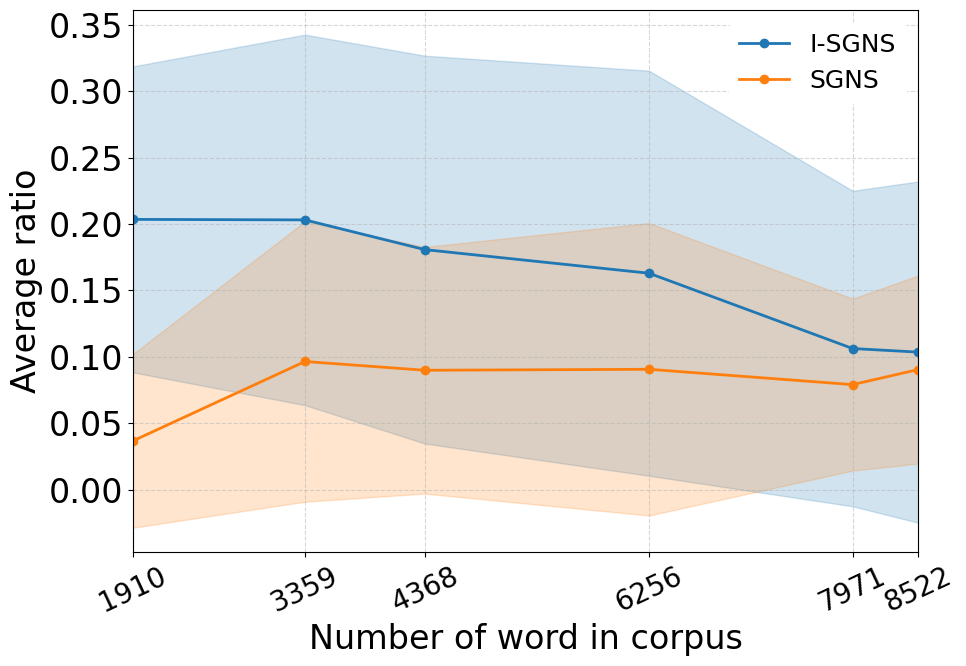

In [10]:
# --- 2. Parse Data (Calculate Means and Stds) ---
corpus_names = list(all_ratio_by_corpus.keys())         # ['GNG', 'IWW']

corpus_names.remove("IWW")
corpus_names.remove("TSGE")
corpus_names.remove("TGTP")
corpus_names.remove("TGTR")

print(corpus_names)

model_names = list(all_ratio_by_corpus[corpus_names[0]].keys()) # ['OneEmb', ...]
model_names.remove("SGNS with intonation")
model_names.remove("My method without intonation")

# We create temporary storage for plotting
# Structure: { 'OneEmb': {'means': [3.8, 4.1], 'stds': [0.5, 0.2]} }
plot_data = {m: {'means': [], 'stds': []} for m in model_names}

for model in model_names:
    for corpus in corpus_names:
        # Get raw values
        print(corpus)
        print(model)
        scores = list(all_ratio_by_corpus[corpus][model].values())
        
        # Calculate stats
        plot_data[model]['means'].append(np.mean(scores))
        plot_data[model]['stds'].append(np.std(scores))

# --- 3. Plotting (Line Plot with Error Bars) ---
fig, ax = plt.subplots(figsize=(10, 7))
plt.rcParams.update({'font.size': 18})

# X-axis coordinates (just 0, 1, 2...)
x_values = [number_word_by_corpus[c] for c in corpus_names]
    
for model in model_names:
    means = np.array(plot_data[model]['means'])
    stds = np.array(plot_data[model]['stds'])
    
    label = "I-SGNS" if model == "My method with intonation" else "SGNS"
    # 1. Plot the main line
    line, = ax.plot(x_values, means, marker='o', linewidth=2, label=label)
    
    # 2. Add the shaded area for STD
    ax.fill_between(x_values, means - stds, means + stds, 
                    color=line.get_color(), alpha=0.2)

# Formatting
# ax.set_title('Average ratio for clusters found for each corpus', fontsize=18)
ax.set_ylabel(f'Average ratio', fontsize=24)
ax.set_xlabel('Number of word in corpus', fontsize=24)

# Set the X-ticks to be the Corpus Names
ax.set_xticks(x_values)
# ax.set_xticklabels(corpus_names, rotation=0, fontsize=14)
ax.set_xticklabels([v for c, v in number_word_by_corpus.items()], rotation=25, fontsize=20)
ax.set_xlim(min(x_values), max(x_values))
plt.yticks(fontsize=24)

# Add Legend and Grid
ax.legend(loc='upper right', framealpha=1, edgecolor="white") # bbox_to_anchor=(1.05, 1)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("scoreByCorpusLength.svg", format='SVG')
plt.show()

[np.float64(0.16106503383844634), np.float64(0.0316388158002401), np.float64(0.08465573936810411), np.float64(0.08410009054556626)]


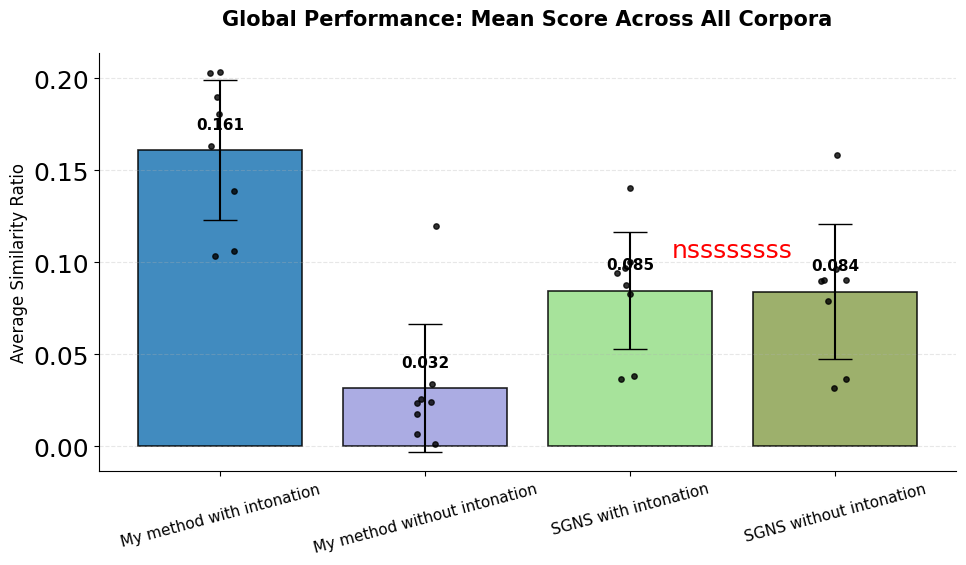

In [20]:
# /!\ completly generate by IA
# --- 1. Calculate Aggregated Global Stats ---
model_global_means = []
model_global_stds = []

corpus_names = list(all_ratio_by_corpus.keys())         # ['GNG', 'IWW']

corpus_names.remove("IWW")
corpus_names.remove("TGTR")

all_model_points = []

all_score = []

# Assuming corpus_names and model_names are already defined from previous steps
model_names = list(all_ratio_by_corpus[corpus_names[0]].keys()) # ['OneEmb', ...]

for model in model_names:
    # 1. Collect the mean score of each corpus for this specific model
    corpus_means = []
    for corpus in corpus_names:
        scores = list(all_ratio_by_corpus[corpus][model].values())
        corpus_means.append(np.mean(scores))
    
    all_model_points.append(corpus_means)
    
    
    # 2. Calculate the Global Mean (Average of the corpus averages)
    model_global_means.append(np.mean(corpus_means))
    # 3. Calculate Global STD (Shows how much the model varies across different corpora)
    model_global_stds.append(np.std(corpus_means))

# --- 2. Plotting the Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(model_names))
# Using a nice color palette
colors = plt.cm.tab20(np.linspace(0., 1., len(model_names)))

colors = [plt.cm.tab20(0), plt.cm.tab20b(3), plt.cm.tab20(5), plt.cm.tab20b(5)]

print(model_global_means)
# Create the bars with error bars for the standard deviation
bars = ax.bar(x, model_global_means, yerr=model_global_stds, 
              capsize=12, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for i, points in enumerate(all_model_points):
    # Add a slight random jitter to the x-coordinates so points don't overlap
    # If you prefer a straight line of points, remove the jitter addition
    jitter = np.random.normal(0, 0.04, size=len(points)) 
    x_coords = np.full(len(points), x[i]) + jitter

    ax.scatter(x_coords, points, color='black', s=15, zorder=3, alpha=0.8) 


# Add value labels on top of bars for exactness
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting for a clean "image" look
ax.set_title('Global Performance: Mean Score Across All Corpora', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Average Similarity Ratio', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11, rotation=15)

# Style adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.text((0+5)*.5, 0.1, "nssssssss", ha='center', va='bottom', color="red")

plt.show()

plot_data = {
    'Model_Name': model_names,
    'Global_Mean': model_global_means,
    'Global_STD': model_global_stds
}

# 2. Create a Pandas DataFrame
df = pd.DataFrame(plot_data)

# 3. Export to CSV (index=False prevents saving the row numbers)
csv_filename = 'model_global_stats.csv'
df.to_csv(csv_filename, index=False)

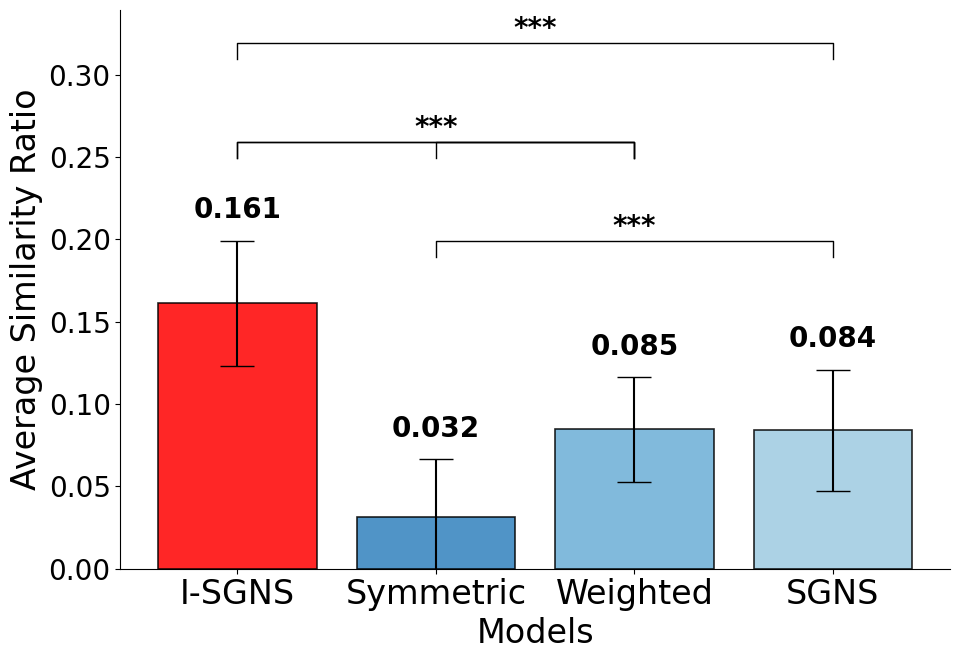

In [20]:
# --- 1. Calculate Aggregated Global Stats ---
model_global_means = []
model_global_stds = []
# Assuming all_ratio_by_corpus is defined previously
corpus_names = list(all_ratio_by_corpus.keys())         

if "IWW" in corpus_names: corpus_names.remove("IWW")
if "TGTR" in corpus_names: corpus_names.remove("TGTR")

all_model_points = []
all_score = []

model_names = list(all_ratio_by_corpus[corpus_names[0]].keys()) 

for model in model_names:
    corpus_means = []
    for corpus in corpus_names:
        scores = list(all_ratio_by_corpus[corpus][model].values())
        corpus_means.append(np.mean(scores))
    
    all_model_points.append(corpus_means)
    model_global_means.append(np.mean(corpus_means))
    model_global_stds.append(np.std(corpus_means))

# --- 2. Plotting the Bar Chart ---
# Increased figure height slightly to make room for brackets at the top
fig, ax = plt.subplots(figsize=(10, 7)) 

x = np.arange(len(model_names))
colors = ['red', plt.cm.tab20c(0), plt.cm.tab20c(1), plt.cm.tab20c(2)]

# Create the bars with error bars
bars = ax.bar(x, model_global_means, yerr=model_global_stds, 
              capsize=12, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

# Scatter points
# for i, points in enumerate(all_model_points):
#     jitter = np.random.normal(0, 0.04, size=len(points)) 
#     x_coords = np.full(len(points), x[i]) + jitter
#     ax.scatter(x_coords, points, color='black', s=15, zorder=3, alpha=0.8) 

# Value labels (Adjusted height to account for error bars so they don't overlap)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + model_global_stds[i] + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

# ==========================================
# 3. STATISTICAL SIGNIFICANCE BRACKETS
# ==========================================
def add_bracket(ax, x1, x2, y, text, tick_height=0.01):
    """Draws a statistical significance bracket between x1 and x2 at height y."""
    # Draw the bracket line
    ax.plot([x1, x1, x2, x2], [y - tick_height, y, y, y - tick_height], lw=1., color='black')
    # Draw the text centered above the line
    ax.text((x1 + x2) * 0.5, y , text, ha='center', va='bottom', color='black', fontsize=20, fontweight='bold')

# Find the highest point on the chart (tallest bar + its error bar) to know where to start stacking
max_y_value = max([m + s for m, s in zip(model_global_means, model_global_stds)])
y_base = max_y_value + 0.0 # Start slightly above the highest point
step = 0.06                 # Vertical distance between bracket levels



add_bracket(ax, 1, 3, y_base, "***")
add_bracket(ax, 0, 2, y_base + step, "")

add_bracket(ax, 0, 2, y_base + (step * 1), "***")
add_bracket(ax, 1, 2, y_base + (step * 1), "")

add_bracket(ax, 0, 3, y_base + (step * 2), "***")

# Set Y-limit to ensure the brackets don't get cut off at the top
ax.set_ylim(0, y_base + (step * 2) + 0.02)
# ==========================================

# Formatting 
# ax.set_title('Global Performance: Mean Score Across All Corpora', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Average Similarity Ratio', fontsize=24)
plt.rcParams.update({'font.size': 20})
ax.set_xlabel('Models', fontsize=24)
ax.set_xticks(x)
ax.set_xticklabels(['I-SGNS', 'Symmetric', 'Weighted', 'SGNS'], fontsize=24, rotation=0)

# Style adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(fname="globalRatio.svg", format="SVG")
plt.show()


# --- 4. Export to CSV ---
plot_data = {
    'Model_Name': model_names,
    'Global_Mean': model_global_means,
    'Global_STD': model_global_stds
}

df = pd.DataFrame(plot_data)
csv_filename = 'model_global_stats.csv'
df.to_csv(csv_filename, index=False)

In [ ]:
corpus_names = list(all_ratio_by_corpus.keys())  
model_names = list(all_ratio_by_corpus[corpus_names[0]].keys()) # We assume that corpus_names[0] have all model
model_names.remove('My method with intonation')
model_names.remove('My method without intonation')

plot_data = {m: {'means': [], 'stds': []} for m in model_names}

for model in model_names:
    for corpus in corpus_names:
        scores = list(all_ratio_by_corpus[corpus][model].values())        
        
        plot_data[model]['means'].append(np.mean(scores))
        plot_data[model]['stds'].append(np.std(scores))
    

x = np.arange(len(corpus_names))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(10, 6))

for model in model_names:
    means = plot_data[model]['means']
    stds = plot_data[model]['stds']
    offset = width * multiplier
    
    rects = ax.bar((x + offset) - width * (len(model_names) - 1) / 2, means, width, yerr=stds, label=model, capsize=5, alpha=0.8)
    ax.bar_label(rects, padding=3, fmt='{:,.2f}')
    multiplier += 1


ax.set_title('Average ratio for clusters found for each corpus', fontsize=14)
ax.set_ylabel(f'Average score \n (average similarity ratio on the pre-training SNGS)', fontsize=12)
ax.set_xlabel('Corpus', fontsize=12)

# Set the X-ticks to be the Corpus Names
ax.set_xticks(x)
ax.set_xticklabels(corpus_names, fontsize=11, rotation=15)

# Add Legend and Grid
ax.legend(title="Models", loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
corpus_names = list(all_ratio_by_corpus.keys())  
model_names = list(all_ratio_by_corpus[corpus_names[0]].keys()) # We assume that corpus_names[0] have all model
model_names.remove('SGNS with intonation')
model_names.remove('SGNS without intonation')

plot_data = {m: {'means': [], 'stds': []} for m in model_names}

for model in model_names:
    for corpus in corpus_names:
        scores = list(all_ratio_by_corpus[corpus][model].values())        
        
        plot_data[model]['means'].append(np.mean(scores))
        plot_data[model]['stds'].append(np.std(scores))
    

x = np.arange(len(corpus_names))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(10, 6))

for model in model_names:
    means = plot_data[model]['means']
    stds = plot_data[model]['stds']
    offset = width * multiplier
    
    rects = ax.bar((x + offset) - width * (len(model_names) - 1) / 2, means, width, yerr=stds, label=model, capsize=5, alpha=0.8)
    ax.bar_label(rects, padding=3, fmt='{:,.2f}')
    multiplier += 1


ax.set_title('Average ratio for clusters found for each corpus', fontsize=14)
ax.set_ylabel(f'Average score \n (average similarity ratio on the pre-training SNGS)', fontsize=12)
ax.set_xlabel('Corpus', fontsize=12)

# Set the X-ticks to be the Corpus Names
ax.set_xticks(x)
ax.set_xticklabels(corpus_names, fontsize=11, rotation=15)

# Add Legend and Grid
ax.legend(title="Models", loc='upper right')
# ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
corpus_names = list(all_ratio_by_corpus.keys())  
model_names = list(all_ratio_by_corpus[corpus_names[0]].keys()) # We assume that corpus_names[0] have all model
model_names.remove('SGNS with intonation')
model_names.remove('My method without intonation')

plot_data = {m: {'means': [], 'stds': []} for m in model_names}

for model in model_names:
    for corpus in corpus_names:
        scores = list(all_ratio_by_corpus[corpus][model].values())        
        
        plot_data[model]['means'].append(np.mean(scores))
        plot_data[model]['stds'].append(np.std(scores))
    

x = np.arange(len(corpus_names))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(10, 6))

for model in model_names:
    means = plot_data[model]['means']
    stds = plot_data[model]['stds']
    offset = width * multiplier
    
    rects = ax.bar((x + offset) - width * (len(model_names) - 1) / 2, means, width, yerr=stds, label=model, capsize=5, alpha=0.8)
    ax.bar_label(rects, padding=3, fmt='{:,.2f}')
    multiplier += 1


ax.set_title('Average ratio for clusters found for each corpus', fontsize=14)
ax.set_ylabel(f'Average score \n (average similarity ratio on the pre-training SNGS)', fontsize=12)
ax.set_xlabel('Corpus', fontsize=12)

# Set the X-ticks to be the Corpus Names
ax.set_xticks(x)
ax.set_xticklabels(corpus_names, fontsize=11, rotation=15)

# Add Legend and Grid
ax.legend(title="Models", loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
corpus_names = list(all_ratio_by_corpus.keys())  
model_names = list(all_ratio_by_corpus[corpus_names[0]].keys()) # We assume that corpus_names[0] have all model
model_names.remove('SGNS without intonation')
model_names.remove('My method with intonation')

plot_data = {m: {'means': [], 'stds': []} for m in model_names}

for model in model_names:
    for corpus in corpus_names:
        scores = list(all_ratio_by_corpus[corpus][model].values())        
        
        plot_data[model]['means'].append(np.mean(scores))
        plot_data[model]['stds'].append(np.std(scores))
    

x = np.arange(len(corpus_names))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(10, 6))

for model in model_names:
    means = plot_data[model]['means']
    stds = plot_data[model]['stds']
    offset = width * multiplier
    
    rects = ax.bar((x + offset) - width * (len(model_names) - 1) / 2, means, width, yerr=stds, label=model, capsize=5, alpha=0.8)
    ax.bar_label(rects, padding=3, fmt='{:,.2f}')
    multiplier += 1


ax.set_title('Average ratio for clusters found for each corpus', fontsize=14)
ax.set_ylabel(f'Average score \n (average similarity ratio on the pre-training SNGS)', fontsize=12)
ax.set_xlabel('Corpus', fontsize=12)

# Set the X-ticks to be the Corpus Names
ax.set_xticks(x)
ax.set_xticklabels(corpus_names, fontsize=11, rotation=15)

# Add Legend and Grid
ax.legend(title="Models", loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
for corpus, values_c in all_ratio_by_corpus.items():
    print(len(values_c["My method with intonation"]))
    

In [ ]:
def create_boxplot_with_points(*data_lists, labels=None, title="Boxplot with Individual Points", y:str="Values"):
    """
    Creates a boxplot for multiple lists and overlays individual data points.
    
    Parameters:
    *data_lists: Variable number of lists/arrays containing numerical data.
    labels: (Optional) A list of strings to label the x-axis groups.
    title: (Optional) Title of the plot.
    """
    
    # Create a new figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. Create the Boxplot
    # We turn off outliers in the boxplot (showfliers=False) because 
    # we are plotting the points manually anyway.
    ax.violinplot(data_lists)
    
    # 2. Plot the Individual Points (with Jitter)
    for i, data in enumerate(data_lists):
        # The x-axis index for boxplots starts at 1, 2, 3...
        x_position = i + 1
        
        # Create random jitter for the x-axis to prevent overlap
        # np.random.normal(mean, standard_deviation, size)
        jitter = np.random.normal(0, 0.04, size=len(data))
        
        # Plot the points: x = position + jitter, y = data values
        ax.scatter(x_position + jitter, data, alpha=0.6, s=25, edgecolor='black', zorder=2)

    # 3. Formatting
    ax.set_title(title)
    ax.set_ylabel(y)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Set custom labels if provided
    if labels:
        if len(labels) == len(data_lists):
            ax.set_xticklabels(labels, rotation=15, ha='center')
        else:
            print("Warning: Number of labels does not match number of data lists.")

    plt.show()

In [ ]:
def create_custom_violinplot(*data_lists, labels=None, title="Customized violin plot", y):
    """
    Creates a customized violin plot with inner boxplot elements (IQR line and median dot).
    """
    
    # Create a new figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 1. Create the Base Violin Plot
    # Turn off default matplotlib lines for whiskers, medians, and means
    parts = ax.violinplot(
        data_lists, 
        showmeans=False, 
        showmedians=False, 
        showextrema=False
    )
    
    # Customize the violin bodies (Red fill, black borders, solid opacity)
    for pc in parts['bodies']:
        pc.set_facecolor('#D43F3A')  # Classic slightly muted red
        pc.set_edgecolor('black')
        pc.set_alpha(1)
        
    # 2. Add Inner Boxplot Elements Manually
    inds = np.arange(1, len(data_lists) + 1)
    
    for i, data in zip(inds, data_lists):
        data = np.asarray(data)
        
        # Calculate statistics
        q1, median, q3 = np.percentile(data, [25, 50, 75])
        whisker_min, whisker_max = np.min(data), np.max(data)
        
        # Draw the thin black line (Whiskers - full range)
        ax.vlines(i, whisker_min, whisker_max, color='black', linestyle='-', lw=1.5)
        
        # Draw the thick black line (Interquartile Range - IQR)
        ax.vlines(i, q1, q3, color='black', linestyle='-', lw=6)
        
        # Draw the white median dot
        ax.scatter(i, median, color='white', zorder=3, s=40)

    # 3. Formatting
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Sample name", fontsize=12)
    ax.set_ylabel(y)
    
    
    # Set custom labels for the x-axis
    ax.set_xticks(inds)
    if labels:
        if len(labels) == len(data_lists):
            ax.set_xticklabels(labels)
        else:
            print("Warning: Number of labels does not match number of data lists.")

    plt.tight_layout()
    plt.show()

# Example usage:
# data1 = np.random.normal(100, 10, 200)
# data2 = np.random.normal(100, 20, 200)
# data3 = np.random.normal(100, 30, 200)
# data4 = np.random.normal(100, 40, 200)
# create_custom_violinplot(data1, data2, data3, data4, labels=['A', 'B', 'C', 'D'])

In [ ]:
corpus = "GNG_IWW_TSGE"
all_clusters = range(0, 30)

for cluster in all_clusters:
    different_score_by_model_in_GNG_and_cl0 = [data[cluster].tolist() for model, data in all_ratio_by_corpus[corpus].items()]
    # create_boxplot_with_points(*different_score_by_model_in_GNG_and_cl0,
                    #         title=f"Cluster {cluster}, ratio of similitude with SGNS pretrain in {corpus}",
                    #         y="Ratio in SGNS pretrain",
                    # labels=["MyModel with intonation", "MyModel without intonation",
                    #         "SGNS with intonation", "SGNS without intonation"])
    
    create_custom_violinplot(*different_score_by_model_in_GNG_and_cl0,
                            title=f"Cluster {cluster}, ratio of similitude with SGNS pretrain in {corpus}",
                            y="Ratio in SGNS pretrain",
                            labels=["MyModel with intonation", "MyModel without intonation",
                            "SGNS with intonation", "SGNS without intonation"])

    f_stat, p_value = f_oneway(*different_score_by_model_in_GNG_and_cl0)
    print(f"f_stat : {f_stat:.5f} , P-value : {p_value:.2e}")

    res = tukey_hsd(*different_score_by_model_in_GNG_and_cl0)
    print(res)

    print(cluster_by_corpus[corpus][cluster])

In [ ]:
def create_boxplot_v2(*data_lists, labels=None, title=None, ylabel="Values", xlabel=None, tukey_result=None, save_path=None):
    """
    Creates a publication-ready boxplot that automatically parses a TukeyHSDResult object.
    
    Parameters:
    *data_lists: Variable number of lists/arrays containing numerical data.
    labels: A list of strings to label the x-axis groups (Required if using tukey_result).
    title: (Optional) Title of the plot.
    ylabel: (Optional) Label for the y-axis.
    xlabel: (Optional) Label for the x-axis.
    tukey_result: (Optional) A TukeyHSDResult object from statsmodels.
    save_path: (Optional) File path to save the plot.
    """
    
    if tukey_result is not None and labels is None:
        raise ValueError("You must provide the 'labels' parameter to map the Tukey results to the boxplots.")

    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    
    # 1. Create the Boxplot
    boxprops = dict(facecolor='#E0E0E0', color='black', linewidth=1.5)
    medianprops = dict(color='#D9534F', linewidth=2.5)
    whiskerprops = dict(color='black', linewidth=1.5)
    capprops = dict(color='black', linewidth=1.5)
    
    ax.boxplot(
        data_lists, showfliers=False, patch_artist=True,
        boxprops=boxprops, medianprops=medianprops,
        whiskerprops=whiskerprops, capprops=capprops, widths=0.6
    )
    
    # 2. Plot the Individual Points
    np.random.seed(42)
    for i, data in enumerate(data_lists):
        x_position = i + 1
        jitter = np.random.normal(0, 0.05, size=len(data))
        ax.scatter(x_position + jitter, data, alpha=0.5, s=30, color='#2C3E50', edgecolor='white', linewidth=0.5, zorder=2)

    # 3. Parse Tukey Results and Add Significance Brackets
    if tukey_result is not None:
        y_max = max([np.max(data) for data in data_lists])
        y_min = min([np.min(data) for data in data_lists])
        y_range = y_max - y_min
        
        bracket_step = y_range * 0.05
        current_y = y_max + bracket_step
        
        # Extract data from the Tukey results table
        # Table format: [group1, group2, meandiff, p-adj, lower, upper, reject]
        tukey_data = tukey_result._results_table.data[1:] 
        
        for row in tukey_data:
            g1, g2, _, p_adj, _, _, reject = row
            
            # Only draw brackets for significant differences
            if reject:
                # Find the corresponding boxplot indices
                # Note: labels must perfectly match the group names in your dataframe!
                idx1 = labels.index(g1)
                idx2 = labels.index(g2)
                
                # Determine standard asterisks based on p-value
                if p_adj <= 0.0001:
                    text = '****'
                elif p_adj <= 0.001:
                    text = '***'
                elif p_adj <= 0.01:
                    text = '**'
                elif p_adj <= 0.05:
                    text = '*'
                else:
                    text = 'ns'
                
                x1 = idx1 + 1
                x2 = idx2 + 1
                
                # Draw the bracket
                ax.plot([x1, x1, x2, x2], 
                        [current_y, current_y + bracket_step, current_y + bracket_step, current_y], 
                        lw=1.2, color='black')
                
                # Add the asterisks
                ax.text((x1 + x2) * 0.5, current_y + bracket_step, text, 
                        ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
                
                current_y += bracket_step * 3.5 

        ax.set_ylim(y_min - (y_range * 0.05), current_y + bracket_step)

    # 4. Publication Formatting
    if title:
        ax.set_title(title, pad=20, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold', labelpad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontweight='bold', labelpad=10)
        
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.yaxis.grid(True, linestyle='-', alpha=0.2, color='gray', zorder=0)
    
    if labels:
        ax.set_xticks(range(1, len(data_lists) + 1))
        ax.set_xticklabels(labels, rotation=0, ha='center')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()

# ==========================================
# --- FULL EXAMPLE WORKFLOW ---
# ==========================================

# 1. Generate Dummy Data mimicking an experiment
np.random.seed(10)
df = pd.DataFrame({
    'Score': np.concatenate([
        np.random.normal(5.5, 0.8, 40),  # School
        np.random.normal(6.5, 0.7, 40),  # College
        np.random.normal(8.5, 0.9, 40)   # University
    ]),
    'Education': ['School']*40 + ['College']*40 + ['University']*40
})

# 2. Run the Tukey HSD Test
tukey = pairwise_tukeyhsd(endog=df['Score'], groups=df['Education'], alpha=0.05)
print(tukey) # Optional: Print the summary table to the console

# 3. Extract the separate lists for the boxplot
school_data = df[df['Education'] == 'School']['Score']
college_data = df[df['Education'] == 'College']['Score']
uni_data = df[df['Education'] == 'University']['Score']

# 4. Plot it! (Make sure 'labels' match the group names in your dataframe exactly)
create_boxplot_v2(
    school_data, college_data, uni_data,
    labels=['School', 'College', 'University'], 
    ylabel="Score",
    xlabel="Education Level",
    tukey_result=tukey
)

In [ ]:
print(all_ratio_by_corpus["GNG"].keys())

In [ ]:
def get_significance(p):
    if p > 0.05: return "ns"
    if p <= 0.0001: return "****"
    if p <= 0.001: return "***"
    if p <= 0.01: return "**"
    return "*"

# Assuming this is the order of your dictionary keys:
# 0: My method with intonation
# 1: My method without intonation
# 2: SGNS with intonation
# 3: SGNS without intonation
model_names = list(all_ratio_by_corpus["GNG"].keys())

# To store results: {corpus: {cluster_id: {comparison: stars}}}
final_results = {}

final_results = {
        "0-1" : [],
        "0-2" : [],
        "0-3" : [],
        "1-2" : [],
        "1-3" : [],
        "2-3" : [],
    }

# for corpus in ["GNG", "TSGE", "TGTP", "GNG_IWW", "GNG_IWW_TSGE", "GNG_IWW_TSGE_TRDP",
#                'GNG_IWW_TSGE_TRDP_TGTP', "GNG_IWW_TSGE_TRDP_TGTP_TGTR"]:
    
for corpus in ["GNG_IWW_TSGE_TRDP_TGTP_TGTR"]:
    nb_cluster = len(all_ratio_by_corpus[corpus]["My method with intonation"])
    
    for cluster_idx in range(nb_cluster):
        cluster_name = cluster_by_corpus[corpus][cluster_idx]
        
        # Extract data for all 4 models for this specific cluster
        data_to_test = [all_ratio_by_corpus[corpus][m][cluster_idx].tolist() for m in model_names]
        
        # Run Tukey HSD
        res = tukey_hsd(*data_to_test)
        p_matrix = res.pvalue
        
        # Store significance for specific pairs (e.g., My method +Int vs -Int)
        # p_matrix[1][0] is comparing model index 1 to model index 0
        # sig_map = {
        #     "My_Int_vs_NoInt": get_significance(p_matrix[0][1]),
        #     "My_vs_SGNS_Int":  get_significance(p_matrix[0][2]),
        #     "SGNS_Int_vs_NoInt": get_significance(p_matrix[2][3])
        # }
        
        final_results["0-1"].append(get_significance(p_matrix[0][1]))
        final_results["0-2"].append(get_significance(p_matrix[0][2]))
        final_results["0-3"].append(get_significance(p_matrix[0][3]))
        final_results["1-2"].append(get_significance(p_matrix[1][2]))
        final_results["1-3"].append(get_significance(p_matrix[1][3]))
        final_results["2-3"].append(get_significance(p_matrix[2][3]))

        
        # Debug print
        print(f"--- Corpus: {corpus} | Cluster: {cluster_name} ---")
        # print(f"My (Int vs NoInt): {sig_map['My_Int_vs_NoInt']} (p={p_matrix[0][1]:.4f})")



In [ ]:
from collections import Counter


counters = {}
counters["Full vs Sym"] = Counter(final_results["0-1"])
counters["Full vs Weight"] = Counter(final_results["0-2"])
counters["Full vs Std"] = Counter(final_results["0-3"])
counters["Sym vs Weight"] = Counter(final_results["1-2"])
counters["Sym vs Std"] = Counter(final_results["1-3"])
counters["Weight vs Std"] = Counter(final_results["2-3"])
print(counters)


categories = ['ns', '*', '**', '***', '****']

# Create a figure with a 2x3 grid of subplots
# sharey=True makes the y-axis scale the same across all plots for easy comparison
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharey=True)

# Flatten the 2D array of axes to easily iterate through them in a 1D loop
axes = axes.flatten()

for i, (title,  counter) in enumerate(counters.items()):
    values = [counter.get(cat, 0) for cat in categories]
    
    axes[i].bar(categories, values, color='skyblue', edgecolor='black')
    
    # Formatting
    axes[i].set_title(title)
    axes[i].set_ylabel('Number of clusters')
    axes[i].tick_params(axis='x', labelsize=12)

# Adjust layout so titles and labels don't overlap
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
for model in model_names:
    # 1. Collect the mean score of each corpus for this specific model
    corpus_means = []
    for corpus in corpus_names:
        print(corpus)
        scores = list(all_ratio_by_corpus[corpus][model].values())
        corpus_means.append(np.mean(scores))
    
    # 2. Calculate the Global Mean (Average of the corpus averages)
    model_global_means.append(np.mean(corpus_means))
    
    # 3. Calculate Global STD (Shows how much the model varies across different corpora)
    model_global_stds.append(np.std(corpus_means))

# --- 2. Plotting the Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(model_names))
# Using a nice color palette
colors = plt.cm.tab20(np.linspace(0., 1., len(model_names)))

colors = [plt.cm.tab20(0), plt.cm.tab20b(3), plt.cm.tab20(5), plt.cm.tab20b(5)]

# Create the bars with error bars for the standard deviation
bars = ax.bar(x, model_global_means, yerr=model_global_stds, 
              capsize=12, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars for exactness
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting for a clean "image" look
ax.set_title('Global Performance: Mean Score Across All Corpora', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Average Similarity Ratio', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11, rotation=15)

# Style adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
corpus = "GNG"
all_clusters = range(0, 30)

for cluster in all_clusters:
    different_score_by_model_in_GNG_and_cl0 = [data[cluster].tolist() for model, data in all_ratio_by_corpus[corpus].items()]
    f_stat, p_value = f_oneway(*different_score_by_model_in_GNG_and_cl0)
    print(f"f_stat : {f_stat:.5f} , P-value : {p_value:.2e}")

    res:TukeyHSDResult = tukey_hsd(*different_score_by_model_in_GNG_and_cl0)
    print(res)
    print(type(res))
    

    print(cluster_by_corpus[corpus][cluster])
    significant_pairs = [
        (0, 1, '*'),     # School vs College
        (0, 2, '****'),  # School vs University
        (1, 2, '****')   # College vs University
    ]
    
    create_boxplot_v2(*different_score_by_model_in_GNG_and_cl0,
                    title=f"Cluster {cluster}, ratio of similitude with SGNS pretrain in {corpus}",
                    ylabel="Ratio in SGNS pretrain", tukey_result=res,
                    labels=["MyModel with intonation", "MyModel without intonation",
                            "SGNS with intonation", "SGNS without intonation"], )

   

In [ ]:

# data_per_model = [row.dropna().values for index, row in df.iterrows()]

# # 3. Run One-Way ANOVA
# f_statistic, p_value = f_oneway(*data_per_model)

# print(f"F-Statistic: {f_statistic}")
# print(f"P-Value: {p_value}")

### Find cluster from trained embedding

In [ ]:
_model = np.load(paths[0])
vectors = _model['vectors']
words = _model['words']

vectors = torch.tensor(vectors)

vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)
sim_matrix = torch.mm(vectors_norm, vectors_norm.t()) 

number_vec = len(vectors)
mask = torch.triu(torch.ones(number_vec, number_vec, device=vectors.device), diagonal=1).bool()
unique_sims = sim_matrix[mask]
print(unique_sims)
all_cosine_similarity = pd.DataFrame(unique_sims, index=words, columns=words)


In [ ]:
sym_matrix = all_cosine_similarity.values
diff = sym_matrix - sym_matrix.T

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Define your distance threshold (e.g., 0.3 means a minimum similarity of 0.7)
distance_threshold = 1.0 - 0.3

# AgglomerativeClustering can compute the distance matrix for you internally
clustering = AgglomerativeClustering(
    n_clusters=None, # None because we are using a distance threshold
    distance_threshold=distance_threshold,
    metric='cosine', 
    linkage='complete'
)

cluster_labels = clustering.fit_predict(vectors.cpu().numpy())

clusters = {}
for word, label in zip(words, cluster_labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(word)
    
print(clusters)

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import scipy.spatial.distance as ssd

dist_matrix = 1.0 - all_cosine_similarity.values
np.fill_diagonal(dist_matrix, 0.0) 

condensed_dist = ssd.squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
distance_threshold = 1.0 - min_similarity
cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')

clusters: dict[int, list[str]] = {}
words = all_cosine_similarity.index

for word, label in zip(words, cluster_labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(word)


### Histogram

In [ ]:
# labels = ["My method with intonation", "My method without intonation", "SGNS with intonation", "SGNS without intonation"]
# for corpus in all_ratio_by_corpus.keys():
#     print(f"Plotting for corpus: {corpus}")
    
#     # Organize data: Key = Cluster Name, Value = List of scores for the 4 methods
#     data = {
#         name_cl: [np.mean(d[name_cl]) for d in all_ratio_by_corpus[corpus].values()] 
#         for name_cl in all_ratio_by_corpus[corpus]["OneEmb"].keys()
#     }

#     width = 0.6
#     fig, ax = plt.subplots(figsize=(10, 8)) # Increased height slightly for readability
#     bottom = np.zeros(len(labels)) # Dynamic length based on labels

#     for name_cl, cl in data.items():
#         p = ax.bar(labels, cl, width, label=name_cl, bottom=bottom)
#         bottom += cl

#         # 1. Add labels and capture the list of Text objects returned
#         labels_text = ax.bar_label(p, label_type='center')

#         # 2. Find min and max for this specific cluster row
#         min_val = min(cl)

#         # 3. Iterate through the text objects and values to bold the extremes
#         for label_obj, val in zip(labels_text, cl):
#             if val == min_val:
#                 label_obj.set_fontweight('bold')
#                 # Optional: You could also change color if bold isn't visible enough
#                 # label_obj.set_color('white') 

#     ax.set_title(f'MAE by cluster in corpus {corpus}')
    
#     # Moving legend outside because stacked bars with labels are crowded
#     ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
#     ax.set_xticklabels(labels, rotation=15, ha='center')
    
#     plt.tight_layout() # Fixes layout issues with rotated labels
#     plt.show()

In [ ]:
print(all_corpus_cluster_MAE_by_model)

$$
\ell = \sum_{w \in V_W} \sum_{c \in V_W} \#(w, w) \left( \log \sigma(\vec{w} \cdot \vec{w}) + k \cdot \mathbb{E}_{c_N \sim P_D} [\log \sigma(-\vec{w} \cdot \vec{w}_N)] \right)


$$

$$
 \cdot \mathbb{E}_{c_N \sim P_D} [\log \sigma(-\vec{w} \cdot \vec{w}_N)]
 $$

In [ ]:
# --- 2. Parse Data (Calculate Means and Stds) ---
corpus_names = list(all_ratio_by_corpus.keys())         # ['GNG', 'IWW']
model_names = list(all_ratio_by_corpus[corpus_names[0]].keys()) # ['OneEmb', ...]

# We create temporary storage for plotting
# Structure: { 'OneEmb': {'means': [3.8, 4.1], 'stds': [0.5, 0.2]} }
plot_data = {m: {'means': [], 'stds': []} for m in model_names}

for model in model_names:
    for corpus in corpus_names:
        # Get raw values
        scores = list(all_ratio_by_corpus[corpus][model].values())
        
        # Calculate stats
        plot_data[model]['means'].append(np.mean(scores))
        plot_data[model]['stds'].append(np.std(scores))

# --- 3. Plotting (Line Plot with Error Bars) ---
fig, ax = plt.subplots(figsize=(10, 6))

# X-axis coordinates (just 0, 1, 2...)
x = np.arange(len(corpus_names))

for model in model_names:
    means = plot_data[model]['means']
    stds = plot_data[model]['stds']
    
    # ax.errorbar is the key function here
    # - marker='o': Adds a dot at the data point
    # - capsize=5: Adds the little horizontal lines on the error bars
    # - linestyle='-': Connects the dots with a line
    # - alpha=0.8: Slightly transparent lines so overlaps are visible
    ax.errorbar(x, means, yerr=stds, label=model, 
                marker='o', capsize=5, linestyle='-', linewidth=2, alpha=0.8)

# Formatting
ax.set_title('Average ratio for clusters found for each corpus', fontsize=14)
ax.set_ylabel(f'Score (ratio by SNGS pre-train)', fontsize=12)
ax.set_xlabel('Corpus', fontsize=12)

# Set the X-ticks to be the Corpus Names
ax.set_xticks(x)
ax.set_xticklabels(corpus_names, fontsize=11)

# Add Legend and Grid
ax.legend(title="Models", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

```py
fig = plt.figure()
x = np.arange(10)
y = 2.5 * np.sin(x / 20 * np.pi)
yerr = np.linspace(0.05, 0.2, 10)

plt.errorbar(x, y + 3, yerr=yerr, label='both limits (default)')

plt.errorbar(x, y + 2, yerr=yerr, uplims=True, label='uplims=True')

plt.errorbar(x, y + 1, yerr=yerr, uplims=True, lolims=True,
             label='uplims=True, lolims=True')

upperlimits = [True, False] * 5
lowerlimits = [False, True] * 5
plt.errorbar(x, y, yerr=yerr, uplims=upperlimits, lolims=lowerlimits,
             label='subsets of uplims and lolims')

plt.legend(loc='lower right')
```

## Ancienne version

In [ ]:
list_of_path_my_met = [f"embedding/TSGE/norm01/seed_{i}_SGNS_OneEmbWeighted_.npz" for i in range(0, 10)]
list_of_path_2_emb_w = [f"embedding/TSGE/norm01/seed_{i}_SGNS_Weighted_.npz" for i in range(0, 10)]
list_of_path_1_emb = [f"embedding/TSGE/noNorm/seed_{i}_OnlyOneEmb_.npz" for i in range(0, 10)]
list_of_path_my_met = [f"embedding/TSGE/norm01/seed_{i}_SGNS_OneEmbWeighted_.npz" for i in range(0, 10)]
list_of_path_2_emb = [f"embedding/TSGE/noNorm/seed_{i}_SkipGramModel_.npz" for i in range(0, 10)]
list_of_path_pretrain = [f"googleW2V/google_sub_embed_TSGE.npz"]

r = range(0, 10)
corpus = "GNG"
list_of_path_my_met = [f"embedding/{corpus}/norm01/seed_{i}_SGNS_OneEmbWeighted_.npz" for i in r]
list_of_path_2_emb_w = [f"embedding/{corpus}/norm01/seed_{i}_SGNS_Weighted_.npz" for i in r]
list_of_path_1_emb = [f"embedding/{corpus}/noNorm/seed_{i}_OnlyOneEmb_.npz" for i in r]
list_of_path_2_emb = [f"embedding/{corpus}/noNorm/seed_{i}_SkipGramModel_.npz" for i in r]
list_of_path_pretrain = [f"googleW2V/google_sub_embed_{corpus}.npz"]

# cluster_to_test = {
#         "cluster_light_TSGE" : cluster_light_TSGE,
#         "cluster_color_TSGE" :cluster_color_TSGE
#     }

cluster_to_test = {i: words for i, (_, _, _, words) in enumerate(cluster_by_corpus[corpus])}
fct_metrics = [compute_distance_rank_by_cluster]
n_random_samples = None

### My method

In [ ]:
result = apply_metrics_with_clusters_in_vectors(
    paths_of_weight=list_of_path_my_met,
    clusters=cluster_to_test,
    fct_metrics=fct_metrics,
    n_random_samples=n_random_samples
)

print(result)
all_result["Our method train with intonation"] = result

### My model 2.0

In [ ]:
result = apply_metrics_with_clusters_in_vectors(
    paths_of_weight=list_of_path_2_emb_w,
    clusters=cluster_to_test,
    fct_metrics=fct_metrics,
    n_random_samples=n_random_samples
)
all_result["SGNS train with intonation"] = result

### Model with only One emb

In [ ]:

result = apply_metrics_with_clusters_in_vectors(
    paths_of_weight=list_of_path_1_emb,
    clusters=cluster_to_test,
    fct_metrics=fct_metrics,
    n_random_samples=n_random_samples
)
all_result["Our method train without intonation"] = result

### Model Original

In [ ]:
result = apply_metrics_with_clusters_in_vectors(
    paths_of_weight=list_of_path_2_emb,
    clusters=cluster_to_test,
    fct_metrics=fct_metrics,
    n_random_samples=n_random_samples
)
all_result["SGNS train without intonation"] = result

### Modèle pre-train

In [ ]:
result = apply_metrics_with_clusters_in_vectors(
    paths_of_weight=list_of_path_pretrain,
    clusters=cluster_to_test,
    fct_metrics=fct_metrics,
    n_random_samples=n_random_samples
)
all_result["SGNS pre-train (google)"] = result

### random

In [ ]:
nb_instance = 50

In [ ]:
name_file = f"embedding/GNG_IWW/norm03/seed_{0}_SGNS_OneEmbWeighted_.npz"
name_file = f"embedding/TS/norm03/seed_{0}_SGNS_OneEmbWeighted_.npz"
# name_file = f"embedding/TS_GNG_IWW/norm03/seed_{0}_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
words = model['words']
for instance in range(nb_instance):
    vectors = np.random.randn(len(words), 10)
    np.savez(
        f'embedding/TS/rand/{instance}_.npz', 
        vectors=vectors,
        words=words
    )

In [ ]:
list_of_path = [f"embedding/rand/{instance}_.npz" for instance in range(nb_instance)]
list_of_path = [f"embedding/TS_GNG_IWW/rand/{instance}_.npz" for instance in range(nb_instance)]

result = apply_metrics_with_clusters_in_vectors(
    paths_of_weight=list_of_path,
    # clusters={
    #     "cluster_animal" : cluster_animal, 
    #     "cluster_word_without_importance" : cluster_word_without_importance,
    #     "cluster_not_bad_word_and_animal" : cluster_sample_not_animal_or_bw,
    # },
    clusters={
        "cluster_animal_IWW" : cluster_animal_IWW,
        "cluster_animal" : cluster_animal,
        "cluster_nature_TS" : cluster_nature_TS, 
        "cluster_clothing_TS" : cluster_clothing_TS,
        "cluster_house_TS" : cluster_house_TS,
    },
    fct_metrics=[compute_distance_rank_by_cluster, my_distance_euclidien],
    n_random_samples=300
)

all_result["Random"] = result

## Visu

### Distance euclidien

In [ ]:
models = list(all_result.keys())
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_animal']["my_distance_euclidien"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []
list_PCA_norm_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []
list_PCA_norm_std = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    print(model)
    print(metric_by_instance)
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    l_pca_norm = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["no_traitement"]["ratio"])
        l_raw_cluster_sim.append(type_distance["norm"]["ratio"])
        l_global_mean.append(type_distance["PCA"]["ratio"])
        l_pca_norm.append(type_distance["PCA and norm"]["ratio"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    list_PCA_norm_mean.append(np.mean(l_pca_norm))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_PCA_norm_std.append(np.std(l_pca_norm))
    
x = np.arange(len(models))  # label locations
width = 0.1                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width * 2, list_z_score_mean, width, yerr=list_z_score_std, 
                label='no traitement', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x - width/2, list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='norm', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width/2, list_global_mean_mean, width, yerr=list_raw_cluster_sim_std, 
                label='pca', capsize=5, color='green', edgecolor='black')
rects4 = ax.bar(x + width *2, list_PCA_norm_mean, width, yerr=list_PCA_norm_std, 
                label='pca norm', capsize=5, color='red', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')
ax.bar_label(rects4, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparison of PCA vs noTraitement across Models in cluster animal')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
    

In [ ]:
models = list(all_result.keys())
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_word_without_importance']["my_distance_euclidien"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []
list_PCA_norm_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []
list_PCA_norm_std = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    print(model)
    print(metric_by_instance)
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    l_pca_norm = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["no_traitement"]["ratio"])
        l_raw_cluster_sim.append(type_distance["norm"]["ratio"])
        l_global_mean.append(type_distance["PCA"]["ratio"])
        l_pca_norm.append(type_distance["PCA and norm"]["ratio"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    list_PCA_norm_mean.append(np.mean(l_pca_norm))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_PCA_norm_std.append(np.std(l_pca_norm))
    
x = np.arange(len(models))  # label locations
width = 0.1                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width * 2, list_z_score_mean, width, yerr=list_z_score_std, 
                label='no traitement', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x - width/2, list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='norm', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width/2, list_global_mean_mean, width, yerr=list_raw_cluster_sim_std, 
                label='PCA', capsize=5, color='green', edgecolor='black')
rects4 = ax.bar(x + width *2, list_PCA_norm_mean, width, yerr=list_PCA_norm_std, 
                label='pca norm', capsize=5, color='red', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')
ax.bar_label(rects4, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparison of PCA vs noTraitement across Models in cluster bad word')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
    

### visu z_score

#### Z score cluster animal and bad word in GNG

In [ ]:
models = list(all_result.keys())
result_all_distance_euclidien = {}
models.remove("Random")
for m in models : 
    result_all_distance_euclidien[m] = all_result[m][1]["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    
    list_z_score.append(l_z_score)
    
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()

# anova = f_oneway(list_z_score[0],list_z_score[1],list_z_score[2],list_z_score[3],list_z_score[4],list_z_score[5])
# print(anova)
    

In [ ]:
models = list(all_result.keys())
result_all_distance_euclidien = {}
models.remove("Random")
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_animal']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    
    list_z_score.append(l_z_score)
    
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster "cluster_animal"')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()

# anova = f_oneway(list_z_score[0],list_z_score[1],list_z_score[2],list_z_score[3],list_z_score[4],list_z_score[5])
# print(anova)
    

In [ ]:
models = list(all_result.keys())
result_all_distance_euclidien = {}
models.remove("Random")
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_color_GNG']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparison of different models trained on TS GNG and IWW for the similarity of colors present in GNG')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()


anova = f_oneway(list_z_score[0],list_z_score[1],list_z_score[2],list_z_score[3],list_z_score[4],list_z_score[5])
print(anova)



In [ ]:
models = list(all_result.keys())
# models.remove('Our method train without intonation')
models.remove( "Random")
result_all_distance_euclidien = {}
for m in models :
    result_all_distance_euclidien[m] = all_result[m]['cluster_word_without_importance']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    
    list_z_score.append(l_z_score)
    
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()

anova = f_oneway(list_z_score[0],list_z_score[1],list_z_score[2],list_z_score[3],list_z_score[4],list_z_score[5])
print(anova)
    

#### Z score in TS GNG and IWW

In [ ]:
# clusters={
#         "cluster_nature_TS" : cluster_nature_TS, 
#         "cluster_clothing_TS" : cluster_clothing_TS,
#         "cluster_house_TS" : cluster_house_TS,
#     },

models = list(all_result.keys())
# models.remove("Our method train with intonation")
# models.remove("Our method train without intonation")
models.remove("Random")
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]["cluster_function_word"]["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster animal v2')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()

In [ ]:
# clusters={
#         "cluster_nature_TS" : cluster_nature_TS, 
#         "cluster_clothing_TS" : cluster_clothing_TS,
#         "cluster_house_TS" : cluster_house_TS,
#     },

models = list(all_result.keys())
# models.remove("Our method train with intonation")
# models.remove("Our method train without intonation")
models.remove("Random")
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_clothing_TS']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster "cluster_clothing_TS"')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()

In [ ]:
# clusters={
#         "cluster_nature_TS" : cluster_nature_TS, 
#         "cluster_clothing_TS" : cluster_clothing_TS,
#         "cluster_house_TS" : cluster_house_TS,
#     },

models = list(all_result.keys())
# models.remove("Our method train with intonation")
# models.remove("Our method train without intonation")
models.remove("Random")
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_house_TS']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster "cluster_house_TS"')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()

In [ ]:
# clusters={
#         "cluster_nature_TS" : cluster_nature_TS, 
#         "cluster_clothing_TS" : cluster_clothing_TS,
#         "cluster_house_TS" : cluster_house_TS,
#     },

models = list(all_result.keys())
# models.remove("Our method train with intonation")
# models.remove("Our method train without intonation")
models.remove("Random")
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_animal']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparison of different models with the animal cluster in GNG (training across the entire corpus)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()


anova = f_oneway(list_z_score[0],list_z_score[1])
print(anova)


In [ ]:
for toto in list_z_score:
    for t in toto:
        print(f"{t}", end='|')
    print()

f_stat, p_value = f_oneway(list_z_score[0], list_z_score[1], list_z_score[2], list_z_score[3])
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4e}") # scientific notation


all_scores = list_z_score[0] + list_z_score[1] + list_z_score[2] + list_z_score[3]
# group_labels = (['Model_A'] * 5) + (['Model_B'] * 5) + (['Model_C'] * 5,) + (['Model_D'] * 5)

# Run Tukey
res = tukey_hsd(list_z_score[0], list_z_score[1], list_z_score[2], list_z_score[3])
print(res)


In [ ]:
# print(list_z_score[-1])

# l1 = list_z_score[][:20]
# l2 = list_z_score[0][20:]
 
# print(f_oneway(l1, l2))

In [ ]:
# clusters={
#         "cluster_nature_TS" : cluster_nature_TS, 
#         "cluster_clothing_TS" : cluster_clothing_TS,
#         "cluster_house_TS" : cluster_house_TS,
#     },

models = list(all_result.keys())
# models.remove("Our method train with intonation")
# models.remove("Our method train without intonation")
models.remove("Random")
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_animal_IWW']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster "cluster_animal_IWW"')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()

In [ ]:
all_scores = list_z_score[0] + list_z_score[1] + list_z_score[2] + list_z_score[3]
f_stat, p_value = f_oneway(list_z_score[0], list_z_score[1], list_z_score[2], list_z_score[3])
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

list_z_score[0] = np.round(list_z_score[0], 3)
list_z_score[1] = np.round(list_z_score[1], 3)
list_z_score[2] = np.round(list_z_score[2], 3)
list_z_score[3] = np.round(list_z_score[3], 3)

res = tukey_hsd(list_z_score[0], list_z_score[1], list_z_score[2], list_z_score[3])
print(res)

#### Z score in TGTR

In [ ]:
models = list(all_result.keys())
# models.remove("Our method train with intonation")
# models.remove("Our method train without intonation")
models.remove("Random")
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_toy_TGTR']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster "toy "')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()

#### Z score in TSGE

In [ ]:
models = list(all_result.keys())
# models.remove("Our method train with intonation")
# models.remove("Our method train without intonation")
models.remove("Random")
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_light_TSGE']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster light TSGE')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()

In [ ]:
models = list(all_result.keys())
# models.remove("Our method train with intonation")
# models.remove("Our method train without intonation")
models.remove("Random")
result_all_distance_euclidien = {}
for m in models : 
    result_all_distance_euclidien[m] = all_result[m]['cluster_color_TSGE']["compute_distance_rank_by_cluster"]
        
list_z_score_mean = []
list_raw_cluster_sim_mean = []
list_global_mean_mean = []

list_z_score_std = []
list_raw_cluster_sim_std = []
list_global_mean_std = []

list_z_score = []
list_raw_cluster_sim = []
list_global_mean = []

for model, metric_by_instance in result_all_distance_euclidien.items():
    l_z_score = []
    l_raw_cluster_sim = []
    l_global_mean = []
    for type_distance in metric_by_instance:
        l_z_score.append(type_distance["z_score"])
        l_raw_cluster_sim.append(type_distance["raw_cluster_sim"])
        l_global_mean.append(type_distance["global_mean"])
        
    list_z_score_mean.append(np.mean(l_z_score))
    list_raw_cluster_sim_mean.append(np.mean(l_raw_cluster_sim))
    list_global_mean_mean.append(np.mean(l_global_mean))
    
    list_z_score_std.append(np.std(l_z_score))
    list_raw_cluster_sim_std.append(np.std(l_raw_cluster_sim))
    list_global_mean_std.append(np.std(l_global_mean))
    list_z_score_mean
    list_z_score.append(l_z_score)
    list_raw_cluster_sim.append(l_raw_cluster_sim)
    list_global_mean.append(l_global_mean)
        
x = np.arange(len(models))  # label locations
width = 0.25                # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width, list_z_score_mean, width, yerr=list_z_score_std, 
                label='z_score', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x , list_raw_cluster_sim_mean, width, yerr=list_raw_cluster_sim_std, 
                label='raw_cluster_sim', capsize=5, color='orange', edgecolor='black')
rects3 = ax.bar(x + width, list_global_mean_mean, width, yerr=list_global_mean_std, 
                label='global_means', capsize=5, color='green', edgecolor='black')

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

# Add labels, title and custom x-axis tick labels
ax.set_ylabel('Mean Score')
ax.set_title('Comparaison of different model using Z score and cluster color TSGE')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()


plt.tight_layout()
plt.savefig('model_comparison_histogram.png')
plt.show()
plt.show()

# Visu embedding

In [ ]:
cluster_animal = ["giraffe", "elephant", "mouse", "lion", "hyena", "armadillo", "gorilla"]
cluster_word_without_importance = ['there', 'is', 'the', 'he', 'has', 'a', 'to', 'you', 'my', 'and', 'that', 'right', 'him', 'doing', 'it', 'at', 'on', 'but', 'doesnot', 'does', 'his', 'with', 'very', 'else', 'itis', 'so', 'this', 'here', 'like', 'still', 'or', 'they', 'how', 'your', 'for', 'them', 'our', 'do', 'i', 'was', 'all', 'go', 'themselves', 'other', 'from', 'their', 'through', 'of', 'just', 'too', 'really', 'as', 'by', 'into', 'even', 'already', 'she', 'her', 'not', 'must', 'be', 'thatis', 'those', 'we', 'others', 'did', 'two', 'because', 'us']

## Compare SGNS std and SGNS full

In [5]:
word_0_intonation_by_corpus = {
    "GNG_IWW_TSGE" : ['the', 'he', 'has', 'a', 'to', 'my', 'and', 'that', 'him', 'it', 'at', 'but', 'doesnot', 'does', 'his', 'with', 'else', 'itis', 'this', 'still', 'or', 'they', 'how', 'your', 'for', 'them', 'our', 'do', 'i', 'was', 'themselves', 'from', 'their', 'through', 'of', 'just', 'too', 'really', 'as', 'by', 'into', 'even', 'already', 'she', 'her', 'not', 'must', 'be', 'thatis', 'those', 'we', 'others', 'did', 'because', 'us', 'an', 'would', 'were', 'giving', 'shall', 'compared', 'its', 'while', 'if', 'will', 'along', 'some', 'kind', 'youre', 'pieces', 'keep', 'many', 'gave', 'then', 'only', 'when', 'almost']
}
name_corpus = "GNG_IWW_TSGE"
base_colors = {
    w : ("red", "red") for w in word_0_intonation_by_corpus[name_corpus]
}

cluster1 = ['animal', 'animals', 'cow', 'horse', 'pig']
cluster2 = ['asleep', 'awake', 'bed', 'sleep', 'sleeping', 'waking']

for w in cluster1:
    base_colors[w] = ("green", "green")
    
for w in cluster2:
    base_colors[w] = ("blue", "blue")

name_file = f"embedding/{name_corpus}/noNorm/seed_0_SkipGramModel_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder1 = {str(value) : index for index, value in enumerate(words)}


emb_pca1 = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=30).fit_transform(vecs)




name_file = f"embedding/{name_corpus}/norm01/seed_4_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder2 = {str(value) : index for index, value in enumerate(words)}


emb_pca2:TSNE = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=30).fit_transform(vecs)



In [9]:
born1 = None
born2 = None


fig = components_to_fig_3D(
    components=emb_pca1,
    encoder=encoder1,
    highlight_words=cluster1 + cluster2 + word_0_intonation_by_corpus[name_corpus],
    nb_neighbors=1, base_color=base_colors, default_point_opacity=0.65, default_point_color="gray",
    legend_axis_X="TSNE 1",
    legend_axis_Y="TSNE 2",
    legend_axis_Z="TSNE 3",
    text_point = ["e"],
    _min=born1, _max = born1,
    text_size=24,
    ticksize=18
)

fig.show()

fig = components_to_fig_3D(
    components=emb_pca2,
    encoder=encoder2,
    highlight_words=cluster1 + cluster2 + word_0_intonation_by_corpus[name_corpus],
    nb_neighbors=1, base_color=base_colors, default_point_opacity=0.65, default_point_color="gray",
    legend_axis_X="TSNE 1",
    legend_axis_Y="TSNE 2",
    legend_axis_Z="TSNE 3",
    text_point = ["aa"],
    _min=born2, _max = born2,
    text_size=24, ticksize=18
)

fig.show()

## SGNS de base

In [ ]:
name_file = f"embedding/GNG_IWW/noNorm/seed_{5}_SkipGramModel_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}
    
base_colors = {
    'giraffe': ("yellow",  "lightyellow"),
    'gorilla': ("yellow", "lightgray"),
    'elephant': ("yellow", "sandybrown"),
    "lion": ("yellow", "lightpink"),
    "mouse": ("yellow", "lightgoldenrodyellow"),
    'hyena' : ("yellow", "lightgoldenrodyellow"),
    'armadillo': ('yellow', 'green'),
    'spot': ('yellow', 'bisque'),
    'finding': ('yellow', 'firebrick'),
}
# pca = PCA(n_components=3)
# emb_pca = pca.fit_transform(vecs)
    
# fig = components_to_fig_3D(
#     components=emb_pca,
#     encoder=encoder,
#     highlight_words=cluster_animal + cluster_word_without_importance,
#     nb_neighbors=1, base_color=base_colors
# )

# fig.show()

# fig = components_to_fig_3D(
#     components=emb_pca,
#     encoder=encoder,
#     highlight_words=cluster_word_without_importance,
#     nb_neighbors=1, base_color=base_colors
# )

# fig.show()

In [ ]:
word_0_intonation_by_corpus = {
    "GNG_IWW_TSGE" : ['the', 'he', 'has', 'a', 'to', 'my', 'and', 'that', 'him', 'it', 'at', 'but', 'doesnot', 'does', 'his', 'with', 'else', 'itis', 'this', 'still', 'or', 'they', 'how', 'your', 'for', 'them', 'our', 'do', 'i', 'was', 'themselves', 'from', 'their', 'through', 'of', 'just', 'too', 'really', 'as', 'by', 'into', 'even', 'already', 'she', 'her', 'not', 'must', 'be', 'thatis', 'those', 'we', 'others', 'did', 'because', 'us', 'an', 'would', 'were', 'giving', 'shall', 'compared', 'its', 'while', 'if', 'will', 'along', 'some', 'kind', 'youre', 'pieces', 'keep', 'many', 'gave', 'then', 'only', 'when', 'almost']
}
name_corpus = "GNG_IWW_TSGE"
base_colors = {
    w : ("red", "red") for w in word_0_intonation_by_corpus[name_corpus]
}
cluster1 = ['animal', 'animals', 'cow', 'horse', 'pig']
cluster2 = ['elephant', 'giraffe', 'gorilla', 'hyena', 'lion', 'monkey']

for w in cluster1:
    base_colors[w] = ("green", "green")
    
for w in cluster2:
    base_colors[w] = ("blue", "blue")

In [ ]:
name_corpus = "GNG_IWW_TSGE"
name_file = f"embedding/{name_corpus}/norm0/seed_0_One.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}


emb_pca = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=30).fit_transform(vecs)

fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster1 + cluster2 + word_0_intonation_by_corpus[name_corpus],
    nb_neighbors=1, base_color=base_colors,
)

fig.show()

In [ ]:
# name_file = f"googleW2V/google_sub_embed_GNG.npz"
# model = np.load(name_file)
# vecs = model['vectors']
# words = model['words']

# # pca = PCA(n_components=3)
# # emb_pca = pca.fit_transform(vecs)

# pca = TSNE(n_components=3)
# emb_pca = pca.fit_transform(vecs)


# for c in cluster_by_corpus["GNG"]:
#     fig = components_to_fig_3D(
#         components=emb_pca,
#         encoder=encoder,
#         highlight_words=c[-1],
#         nb_neighbors=1, base_color=base_colors
#     )

#     fig.show()

## Different norm

In [ ]:
name_file = f"embedding/GNG/norm01/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']


In [ ]:
name_file = f"embedding/GNG/norm01/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}
    
base_colors = {
    'banana': ("yellow",  "lightyellow"),
    'gorilla': ("gray", "lightgray"),
    'zookeeper': ("brown", "sandybrown"),
    "little": ("pink", "lightpink"),
    "yellow": ("gold", "lightgoldenrodyellow"),
    'light' : ("gold", "lightgoldenrodyellow"),
    'turned': ('limegreen', 'green'),
    'spot': ('beige', 'bisque'),
    'finding': ('red', 'firebrick'),
}

# pca = PCA(n_components=3)
# emb_pca = pca.fit_transform(vecs)
    
# fig = components_to_fig_3D(
#     components=emb_pca,
#     encoder=encoder,
#     highlight_words=cluster_animal,
#     nb_neighbors=1, base_color=base_colors
# )

# fig.show()

# fig = components_to_fig_3D(
#     components=emb_pca,
#     encoder=encoder,
#     highlight_words=cluster_word_without_importance,
#     nb_neighbors=1, base_color=base_colors
# )

# fig.show()

In [ ]:
name_corpus = "GNG_IWW_TSGE_TRDP_TGTP_TGTR"
name_file = f"embedding/{name_corpus}/norm01/seed_0_SGNS_OneEmbWeighted_.npz"

model = np.load(name_file)
vecs = model['vectors']
words = model['words']

# pca = PCA(n_components=3)
# emb_pca = pca.fit_transform(vecs)

emb_pca = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=30).fit_transform(vecs)


decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}


for c in cluster_by_corpus[name_corpus]:
    fig = components_to_fig_3D(
        components=emb_pca,
        encoder=encoder,
        highlight_words=c[-1],
        nb_neighbors=1, base_color=base_colors
    )

    fig.show()
    

In [ ]:
name_file = f"embedding/GNG/norm01/seed_18_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}
    
base_colors = {
    'giraffe': ("yellow",  "lightyellow"),
    'gorilla': ("yellow", "lightgray"),
    'elephant': ("yellow", "sandybrown"),
    "lion": ("yellow", "lightpink"),
    "mouse": ("yellow", "lightgoldenrodyellow"),
    'hyena' : ("yellow", "lightgoldenrodyellow"),
    'armadillo': ('yellow', 'green'),
    'spot': ('yellow', 'bisque'),
    'finding': ('yellow', 'firebrick'),
}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
    
fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_animal + cluster_word_without_importance,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_word_without_importance,
    nb_neighbors=1, base_color=base_colors
)

fig.show()


emb_tsne= TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(vecs)

fig = components_to_fig_3D(
    components=emb_tsne,
    encoder=encoder,
    highlight_words=cluster_word_without_importance,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

In [ ]:
name_file = f"embedding/GNG_IWW/norm03/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}
    
base_colors = {
    'banana': ("yellow",  "lightyellow"),
    'gorilla': ("gray", "lightgray"),
    'zookeeper': ("brown", "sandybrown"),
    "little": ("pink", "lightpink"),
    "yellow": ("gold", "lightgoldenrodyellow"),
    'light' : ("gold", "lightgoldenrodyellow"),
    'turned': ('limegreen', 'green'),
    'spot': ('beige', 'bisque'),
    'finding': ('red', 'firebrick'),
}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
    
fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_animal,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_word_without_importance,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

## Two emb weighted

In [ ]:
name_file = f"embedding/GNG_IWW/norm03/seed_0_SGNS_Weighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}
    
base_colors = {
    'banana': ("yellow",  "lightyellow"),
    'gorilla': ("gray", "lightgray"),
    'zookeeper': ("brown", "sandybrown"),
    "little": ("pink", "lightpink"),
    "yellow": ("gold", "lightgoldenrodyellow"),
    'light' : ("gold", "lightgoldenrodyellow"),
    'turned': ('limegreen', 'green'),
    'spot': ('beige', 'bisque'),
    'finding': ('red', 'firebrick'),
}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
    
fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_animal,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_word_without_importance,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

In [ ]:
name_file = f"embedding/norm03/seed_0_SGNS_Weighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}
    
base_colors = {
    'banana': ("yellow",  "lightyellow"),
    'gorilla': ("gray", "lightgray"),
    'zookeeper': ("brown", "sandybrown"),
    "little": ("pink", "lightpink"),
    "yellow": ("gold", "lightgoldenrodyellow"),
    'light' : ("gold", "lightgoldenrodyellow"),
    'turned': ('limegreen', 'green'),
    'spot': ('beige', 'bisque'),
    'finding': ('red', 'firebrick'),
}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
    
fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_animal,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_word_without_importance,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

In [ ]:
name_file = f"embedding/norm02/seed_0_SGNS_Weighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']
decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}
    
base_colors = {
    'banana': ("yellow",  "lightyellow"),
    'gorilla': ("gray", "lightgray"),
    'zookeeper': ("brown", "sandybrown"),
    "little": ("pink", "lightpink"),
    "yellow": ("gold", "lightgoldenrodyellow"),
    'light' : ("gold", "lightgoldenrodyellow"),
    'turned': ('limegreen', 'green'),
    'spot': ('beige', 'bisque'),
    'finding': ('red', 'firebrick'),
}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
    
fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_animal,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_word_without_importance,
    nb_neighbors=1, base_color=base_colors
)

fig.show()


## See cluster by intonation

In [ ]:
name_file = f"embedding/GNG_IWW/norm03/seed_0_SGNS_Weighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

print(words[:10])
print(cluster_word_without_importance[:10])
fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=words,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

In [ ]:
data_intonation = pd.read_csv("data/intonation_word_GNG.csv", index_col=0)
data_intonation = pd.read_csv("data/intonation_word_GNG_IWW.csv", index_col=0)
print(data_intonation)

base_colors = {
    'banana': ("yellow",  "lightyellow"),
    'gorilla': ("gray", "lightgray"),
    'zookeeper': ("brown", "sandybrown"),
    "little": ("pink", "lightpink"),
    "yellow": ("gold", "lightgoldenrodyellow"),
    'light' : ("gold", "lightgoldenrodyellow"),
    'turned': ('limegreen', 'green'),
    'spot': ('beige', 'bisque'),
    'finding': ('red', 'firebrick'),
}

for t in data_intonation["range"].to_dict().items():
    if t[1] == '0-1':
        base_colors[t[0]] = "black"
    if t[1] == '1-2':
        base_colors[t[0]] = "orange"
    if t[1] == '2-3':
        base_colors[t[0]] = "blue"
    if t[1] == '3-4':
        base_colors[t[0]] = "green"
    if t[1] == '4-5':
        base_colors[t[0]] = "red"

In [ ]:
# name_file = f"embedding/norm01/seed_0_SGNS_OneEmbWeighted_.npz"
# model = np.load(name_file)
# vecs = model['vectors']
# words = model['words']

# decoder = {index : str(value) for index, value in enumerate(words)}
# encoder = {str(value) : index for index, value in enumerate(words)}

# pca = PCA(n_components=3)
# emb_pca = pca.fit_transform(vecs)
# fig = components_to_fig_3D_simple(
#     components=emb_pca,
#     encoder=encoder,
#     base_color=base_colors
# )

# fig.show()

name_file = f"embedding/GNG_IWW/norm03/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors
)

fig.show()

# name_file = f"embedding/norm03/seed_0_SGNS_OneEmbWeighted_.npz"
# model = np.load(name_file)
# vecs = model['vectors']
# words = model['words']

# decoder = {index : str(value) for index, value in enumerate(words)}
# encoder = {str(value) : index for index, value in enumerate(words)}

# pca = PCA(n_components=3)
# emb_pca = pca.fit_transform(vecs)
# fig = components_to_fig_3D_simple(
#     components=emb_pca,
#     encoder=encoder,
#     base_color=base_colors
# )

# fig.show()

### fig planisphère

In [ ]:
name_file = f"embedding/GNG_IWW/norm03/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
norms = np.linalg.norm(emb_pca, axis=1, keepdims=True)
norms[norms == 0] = 1e-10 
vectors_norm = emb_pca / norms
fig = components_to_fig_3D_simple(
    components=vectors_norm,
    encoder=encoder,
    base_color=base_colors
)

fig.show()

name_file = f"embedding/norm02/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
norms = np.linalg.norm(emb_pca, axis=1, keepdims=True)
norms[norms == 0] = 1e-10 
vectors_norm = emb_pca / norms
fig = components_to_fig_3D_simple(
    components=vectors_norm,
    encoder=encoder,
    base_color=base_colors
)
fig.show()

name_file = f"embedding/GNG_IWW/norm03/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
norms = np.linalg.norm(emb_pca, axis=1, keepdims=True)
norms[norms == 0] = 1e-10 
vectors_norm = emb_pca / norms
fig = components_to_fig_3D_simple(
    components=vectors_norm,
    encoder=encoder,
    base_color=base_colors
)
fig.show()

In [ ]:
x = vectors_norm[:, 0]
y = vectors_norm[:, 1]
z = vectors_norm[:, 2]

# 2. Calculate the radius
r = np.sqrt(x**2 + y**2 + z**2)

azimuth_radians = np.arctan2(y, x)
elevation_radians = np.arcsin(z / r)

idx_to_word = {idx: word for word, idx in encoder.items()}
words_ordered = [idx_to_word.get(i, f"vec_{i}") for i in range(vectors_norm.shape[0])]

colors = [base_colors.get(w, "gray") for w in words_ordered]

fig = plt.figure()
ax = fig.add_subplot(111, projection='mollweide')

ax.scatter(azimuth_radians, elevation_radians)
plt.show()

In [ ]:
fig = components_to_fig_mollweide(    components=emb_pca,
    encoder=encoder,
    base_color=base_colors)
fig.show()

# Other

In [ ]:
name_file = f"embedding/GNG_IWW/norm02/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
cluster_IWW = ["cat", "cow", "horse", "duck", "pig", "dog"]
for w_IWW in cluster_IWW:
    base_colors[w_IWW] = ("green", "lightyellow")
    
for w_gng in cluster_animal:
    base_colors[w_gng] = ("blue", "lightyellow")
print(base_colors)
print(cluster_IWW)
print(cluster_animal)
cluster_IWW.extend(cluster_animal)
print(cluster_IWW)
fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_IWW,
    words_display=None,
    nb_neighbors=1, base_color=base_colors
)

fig.show()

fig = components_to_fig_3D(
    components=emb_pca,
    encoder=encoder,
    highlight_words=cluster_IWW,
    words_display=cluster_IWW,
    nb_neighbors=1, base_color=base_colors
)
fig.show()

In [ ]:
name_file = f"embedding/GNG_IWW/norm02/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

base_colors = {}
data_intonation = pd.read_csv("data/intonation_word_GNG_IWW.csv", index_col=0)
for t in data_intonation["range"].to_dict().items():
    if t[1] == '0-1':
        base_colors[t[0]] = "black"
    if t[1] == '1-2':
        base_colors[t[0]] = "orange"
    if t[1] == '2-3':
        base_colors[t[0]] = "blue"
    if t[1] == '3-4':
        base_colors[t[0]] = "green"
    if t[1] == '4-5':
        base_colors[t[0]] = "red"
data_intonation = pd.read_csv("data/intonation_word_GNG.csv", index_col=0)
for t in data_intonation["range"].to_dict().items():
    if t[1] == '0-1':
        base_colors[t[0]] = "black"
    if t[1] == '1-2':
        base_colors[t[0]] = "orange"
    if t[1] == '2-3':
        base_colors[t[0]] = "blue"
    if t[1] == '3-4':
        base_colors[t[0]] = "green"
    if t[1] == '4-5':
        base_colors[t[0]] = "red"


pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors,
    default_color="purple"
)

fig.show()

In [ ]:
data_intonation_IWW:pd.DataFrame = pd.read_csv("data/intonation_word_IWW.csv", index_col=0)
data_intonation_GNG:pd.DataFrame = pd.read_csv("data/intonation_word_GNG.csv", index_col=0)
word_in_commun = data_intonation_IWW.index.intersection(data_intonation_GNG.index)
word_only_IWW = data_intonation_IWW.index.difference(word_in_commun)
word_only_GNG = data_intonation_GNG.index.difference(word_in_commun)

print("word in commun : ", len(word_in_commun))
print(f"Number of words only in IWW {len(word_only_IWW)}, in {len(data_intonation_IWW.index)} of words")
print(f"Number of words only in GNG {len(word_only_GNG)}, in {len(data_intonation_GNG.index)} of words")

In [ ]:
base_colors = {}

for w in word_in_commun:
    base_colors[w] = "orange"
    
for w in word_only_IWW:
    base_colors[w] = "green"
    
for w in word_only_GNG:
    base_colors[w] = "blue"
    
name_file = f"embedding/GNG_IWW/norm02/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']
pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
encoder = {str(value) : index for index, value in enumerate(words)}
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors,
    default_color="purple"
)
fig.show()

name_file = f"embedding/GNG_IWW/norm03/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']
encoder = {str(value) : index for index, value in enumerate(words)}
pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors,
    default_color="purple"
)

fig.show()

# Visu emb of SGNS train with intonation in TS (GNG and IWW)

## SGNS train with intonation

In [ ]:
name_file = f"embedding/TS_GNG_IWW/norm03/seed_0_SGNS_Weighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
for n_TS in cluster_nature_TS:
    base_colors[n_TS] = "green"
    
for c_TS in cluster_clothing_TS:
    base_colors[c_TS] = "blue"

for h_TS in cluster_house_TS:
    base_colors[h_TS] ="black"
    
h_w = cluster_nature_TS
h_w.extend(cluster_clothing_TS)
h_w.extend(cluster_house_TS)
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors
)
fig.show()


## SGNS without intonation

In [ ]:
name_file = f"embedding/TS_GNG_IWW/noNorm/seed_5_SkipGramModel_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
for n_TS in cluster_nature_TS:
    base_colors[n_TS] = "green"
    
for c_TS in cluster_clothing_TS:
    base_colors[c_TS] = "blue"

for h_TS in cluster_house_TS:
    base_colors[h_TS] = "black"
    
h_w = cluster_nature_TS
h_w.extend(cluster_clothing_TS)
h_w.extend(cluster_house_TS)
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors
)
fig.show()



## My method

In [ ]:
name_file = f"embedding/TS_GNG_IWW/norm03/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
for n_TS in cluster_nature_TS:
    base_colors[n_TS] = "green"
    
for c_TS in cluster_clothing_TS:
    base_colors[c_TS] = "blue"

for h_TS in cluster_house_TS:
    base_colors[h_TS] = "black"
    
h_w = cluster_nature_TS
h_w.extend(cluster_clothing_TS)
h_w.extend(cluster_house_TS)
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors
)
fig.show()



In [ ]:
name_file = f"embedding/TS/norm03/seed_0_SGNS_OneEmbWeighted_.npz"
model = np.load(name_file)
vecs = model['vectors']
words = model['words']

decoder = {index : str(value) for index, value in enumerate(words)}
encoder = {str(value) : index for index, value in enumerate(words)}

pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
for n_TS in cluster_nature_TS:
    base_colors[n_TS] = "green"
    
for c_TS in cluster_clothing_TS:
    base_colors[c_TS] = "blue"

for h_TS in cluster_house_TS:
    base_colors[h_TS] = "black"
    
h_w = cluster_nature_TS
h_w.extend(cluster_clothing_TS)
h_w.extend(cluster_house_TS)
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors,
    _min=-1,
    _max=1
)
fig.show()

# Visu embedding

In [ ]:
liste_color = ["blue", "red", "green", "yellow", "pink", "orange", "brown"]

In [ ]:
model = np.load(f"embedding/GNG/norm01/seed_{0}_SGNS_OneEmbWeighted_.npz")
words_GNG = model['words'].tolist()
model = np.load(f"embedding/IWW/norm01/seed_{0}_SGNS_OneEmbWeighted_.npz")
words_IWW = model['words'].tolist()
model = np.load(f"embedding/TS/norm01/seed_{0}_SGNS_Weighted_.npz")
words_TS = model['words'].tolist()
model = np.load(f"embedding/TSGE/norm01/seed_{0}_SGNS_Weighted_.npz")
words_TSGE = model['words'].tolist()


not_in_only_GNG = set(words_TS).union(set(words_IWW)).difference(set(words_GNG))
print(not_in_only_GNG)
in_GNG_and_Other = set(words_GNG).intersection(set(words_TS).union(set(words_IWW)))
print(in_GNG_and_Other)
print(in_GNG_and_Other.intersection(['monkey']))

print(set(words_TSGE).intersection(['monkey']))

## My method

In [ ]:
model = np.load(f"embedding/GNG/norm01/seed_{0}_SGNS_OneEmbWeighted_.npz")
vecs = model['vectors']
words = model['words']
encoder = {str(value) : index for index, value in enumerate(words)}
pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
for (name_cluster, cluster), color in zip(cluster_to_test.items(),  liste_color[:len(cluster_to_test)]):
    for w in cluster :
        base_colors[w] = color

fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors,
    default_color="gray",
    default_opacity=0.3,
    _min=-1.,
    _max=1.
)

fig.show()


In [ ]:
model = np.load(f"embedding/TS_GNG_IWW/norm01/seed_{0}_SGNS_OneEmbWeighted_.npz")
vecs = model['vectors']
words = model['words']
encoder = {str(value) : index for index, value in enumerate(words)}
pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
for (name_cluster, cluster), color in zip(cluster_to_test.items(),  liste_color[:len(cluster_to_test)]):
    for w in cluster :
        base_colors[w] = color

fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors,
    default_color="gray",
    default_opacity=0.3,
    _min=-1.,
    _max=1.
)

fig.show()

# base_colors = {}
# for w in words:
#     if w in words_GNG :
#         if w in words_TS and w in words_IWW :
#             base_colors[w] = 'red'
#         else :  
#             base_colors[w] = 'blue'
#     else :
#         base_colors[w] = 'green'

# fig = components_to_fig_3D_simple(
#     components=emb_pca,
#     encoder=encoder,
#     base_color=base_colors,
#     default_color="gray",
#     default_opacity=0.3,
#     _min=-1.,
#     _max=1.
# )

# fig.show()
    

In [ ]:
model = np.load(f"embedding/GNG/noNorm/seed_{0}_SkipGramModel_.npz")
vecs = model['vectors']
words = model['words']
encoder = {str(value) : index for index, value in enumerate(words)}
pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
for (name_cluster, cluster), color in zip(cluster_to_test.items(),  liste_color[:len(cluster_to_test)]):
    for w in cluster :
        base_colors[w] = color
            
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors,
    default_color="gray",
    default_opacity=0.3
)

fig.show()
    

In [ ]:
model = np.load(f"embedding/TS_GNG_IWW/noNorm/seed_{0}_SkipGramModel_.npz")
vecs = model['vectors']
words = model['words']
encoder = {str(value) : index for index, value in enumerate(words)}
pca = PCA(n_components=3)
emb_pca = pca.fit_transform(vecs)

base_colors = {}
for (name_cluster, cluster), color in zip(cluster_to_test.items(),  liste_color[:len(cluster_to_test)]):
    for w in cluster :
        base_colors[w] = color
            
fig = components_to_fig_3D_simple(
    components=emb_pca,
    encoder=encoder,
    base_color=base_colors,
    default_color="gray",
    default_opacity=0.3
)

fig.show()